# Partie 2 — Intégration des Covariables Environnementales
## Ablation Study : Sentinel-2 + Climat + Sol + Topographie

**Ce notebook part directement des CSV existants (pas besoin de relancer la Partie 1)**

### Covariables choisies :
| Type | Variables | Justification |
|---|---|---|
| **Climat** | mean_2m_air_temperature, total_precipitation, dewpoint_2m_temperature | Température et pluie dictent la phénologie ; le dewpoint capte le stress hydrique |
| **Sol** | pH in H2O, Organic Carbon, Texture Class | pH = fertilité ; OC = qualité du sol ; Texture = rétention d'eau |
| **Topographie** | Elevation, Landforms | Altitude et forme de terrain influencent drainage et microclimat |

### 5 configurations d'ablation study :
1. **S2 seul** (baseline)
2. **S2 + Climat**
3. **S2 + Sol**
4. **S2 + Topographie**
5. **S2 + Tout** (toutes covariables)

## 📦 Imports

In [1]:
import numpy as np
import pandas as pd
import datetime
import math, warnings
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, cohen_kappa_score, f1_score
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.grid'] = False

# GEE

print(f'PyTorch : {torch.__version__}')
print(f'GEE     : OK')
print(f'GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

PyTorch : 2.5.1+cu121
GEE     : OK
GPU     : NVIDIA GeForce RTX 4050 Laptop GPU


## ⚙️ Configuration

In [2]:
PROCESSED_DIR = Path('data/processed')
MODEL_DIR     = Path('models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Hyperparamètres globaux ───────────────────────────────────────────────────
N_BANDS      = 10
N_DATES      = 36
BATCH_SIZE   = 64    # ✅ augmenté pour réduire overfitting
LR           = 3e-4  # ✅ réduit pour limiter l'overfitting (gap 12-20%)
EPOCHS       = 400   # marge pour early stopping avec patience=50
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ── Dimensions exactes par configuration ─────────────────────────────────────
# S2_only    : 10 × 36 = 360   features
# S2_climate : 13 × 36 = 468   features  (+Temp, Precip, Dewpoint)
# S2_soil    : 13 × 36 = 468   features  (+pH, OC, Texture)
# S2_topo    : 12 × 36 = 432   features  (+Elevation, Landforms)
# S2_all     : 18 × 36 = 648   features  (+Temp,Precip,Dew,pH,OC,Tex,Elev,LF)

# ── Régularisation adaptée au nombre de features par config ──────────────────
# Observation : S2+soil et S2+all montrent un overfitting sur CA (gap F1 > 7%)
# → dropout et weight_decay renforcés pour les configs à haute dimensionnalité
# ── Régularisation anti-overfitting — renforcée pour toutes les configs ──────
# Gap train-val observé : 12-20% sur CA et AR → overfitting généralisé
# (petit dataset : 240 train / 60 val par classe)
# Actions sans toucher à l'architecture ni à l'augmentation :
#   • dropout 0.5 partout (propagé Transformer + FC)
#   • weight_decay 1e-3 partout
#   • label_smoothing 0.15 partout
#   • patience réduit pour early stop plus tôt
CONFIG_REGULARIZATION = {
    'S2_only'   : {'dropout': 0.5, 'weight_decay': 1e-3, 'patience': 25,
                   'label_smoothing': 0.15},
    'S2_climate': {'dropout': 0.5, 'weight_decay': 1e-3, 'patience': 25,
                   'label_smoothing': 0.15},
    'S2_topo'   : {'dropout': 0.5, 'weight_decay': 1e-3, 'patience': 25,
                   'label_smoothing': 0.15},
    'S2_soil'   : {'dropout': 0.5, 'weight_decay': 1e-3, 'patience': 20,
                   'label_smoothing': 0.15},
    'S2_all'    : {'dropout': 0.5, 'weight_decay': 1e-3, 'patience': 20,
                   'label_smoothing': 0.15},
}

# ── Chemins CSV ───────────────────────────────────────────────────────────────
CSV_CA = Path('data/processed/CALIFORNIA_FULL_split.csv')  # ✅ covariables + split fixe
CSV_AR = Path('data/processed/ARKANSAS_FULL_split.csv')    # ✅ covariables + split fixe


LABEL_MAP_AR = {1: 'Corn', 2: 'Cotton', 3: 'Rice', 5: 'Soybeans', 999: 'Others'}  # ✅ codes CDL corrects
AR_ORDER     = ['Soybeans', 'Rice', 'Corn', 'Cotton', 'Others']

LABEL_MAP_CA = {3: 'Rice', 36: 'Alfalfa', 69: 'Grapes', 75: 'Almonds',
                204: 'Pistachios', 999: 'Others'}  # ✅ codes CDL corrects
CA_ORDER     = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']

CONFIGS = ['S2_only', 'S2_climate', 'S2_soil', 'S2_topo', 'S2_all']

print(f'Device : {DEVICE}')
print(f'CSV CA : {CSV_CA.exists()}')
print(f'CSV AR : {CSV_AR.exists()}')
print()
print(f'{"Config":<15} {"Bandes":>6} {"Features":>9} {"Dropout":>8} {"WD":>8} {"Patience":>9}')
print('-' * 60)
n_bands_map = {'S2_only':10,'S2_climate':13,'S2_soil':13,'S2_topo':12,'S2_all':18}
for cfg in CONFIGS:
    r = CONFIG_REGULARIZATION[cfg]
    nb_ = n_bands_map[cfg]
    print(f'{cfg:<15} {nb_:>6} {nb_*N_DATES:>9} '
          f'{r["dropout"]:>8.1f} {r["weight_decay"]:>8.0e} {r["patience"]:>9}')


Device : cuda
CSV CA : True
CSV AR : True

Config          Bandes  Features  Dropout       WD  Patience
------------------------------------------------------------
S2_only             10       360      0.5    1e-03        25
S2_climate          13       468      0.5    1e-03        25
S2_soil             13       468      0.5    1e-03        20
S2_topo             12       432      0.5    1e-03        25
S2_all              18       648      0.5    1e-03        20


## 📊 VISUALISATIONS — Partie 2

1. **NDVI moyen par culture** (AR + CA) — données réelles CSV Partie 2
2. **Comparaison Partie 1 vs Partie 2** — OA, Kappa, F1 pour S2_only et S2_all
3. **Ablation study intra-Partie 2** — comparaison des 5 configs par région
4. **Radar chart** — profil multi-métrique par config et région
5. **Delta F1** — gain/perte vs baseline S2_only


⚠️  Entraînement non exécuté — utilisation de valeurs placeholder

📊 Figure 1 — NDVI par culture...


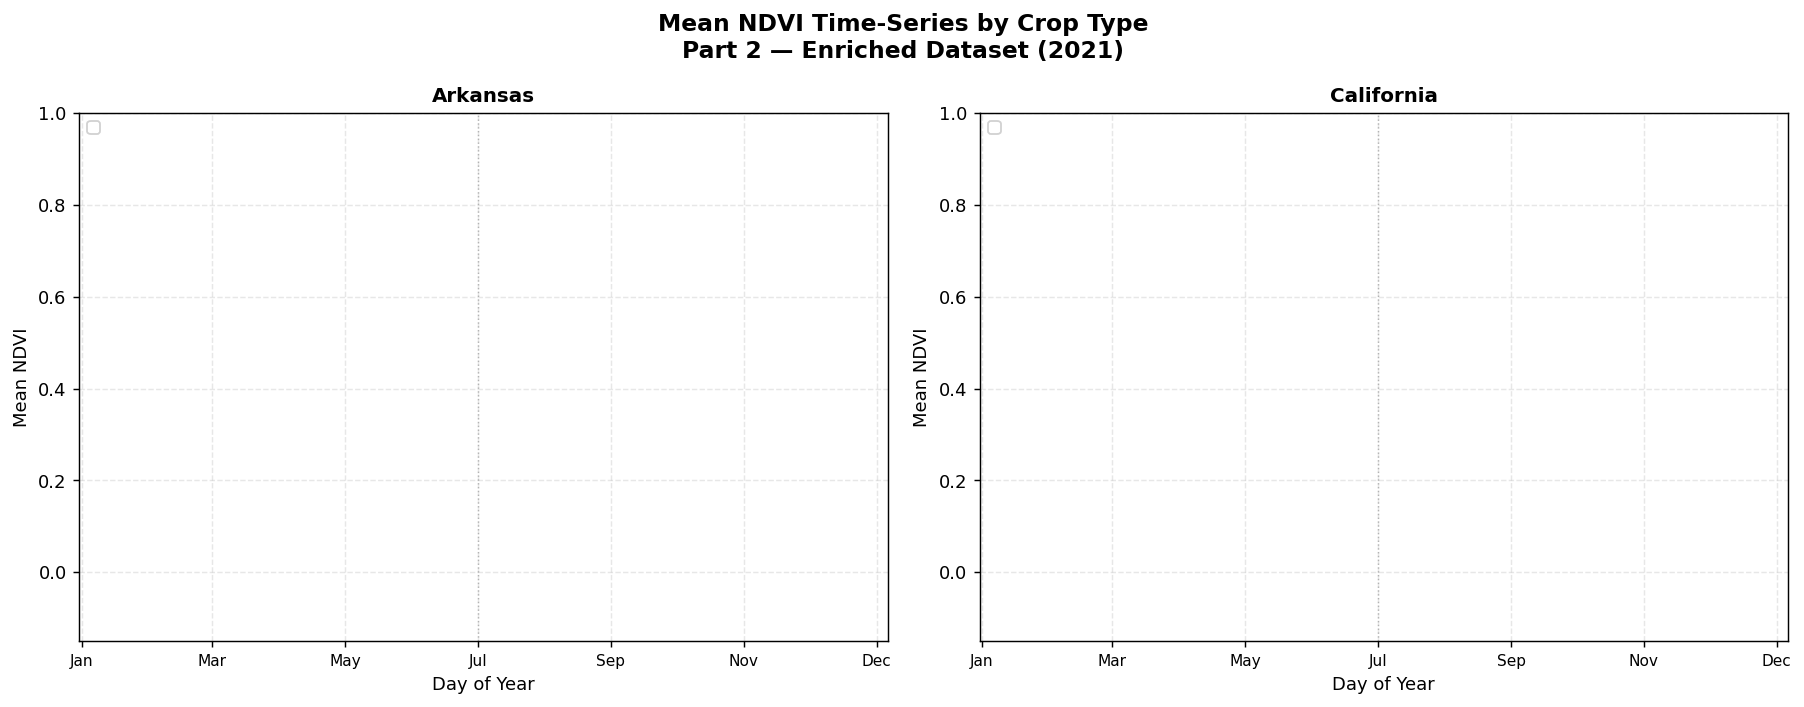

  ✅ Sauvegardé : ndvi_partie2.png

📊 Figure 2 — Partie 1 vs Partie 2...


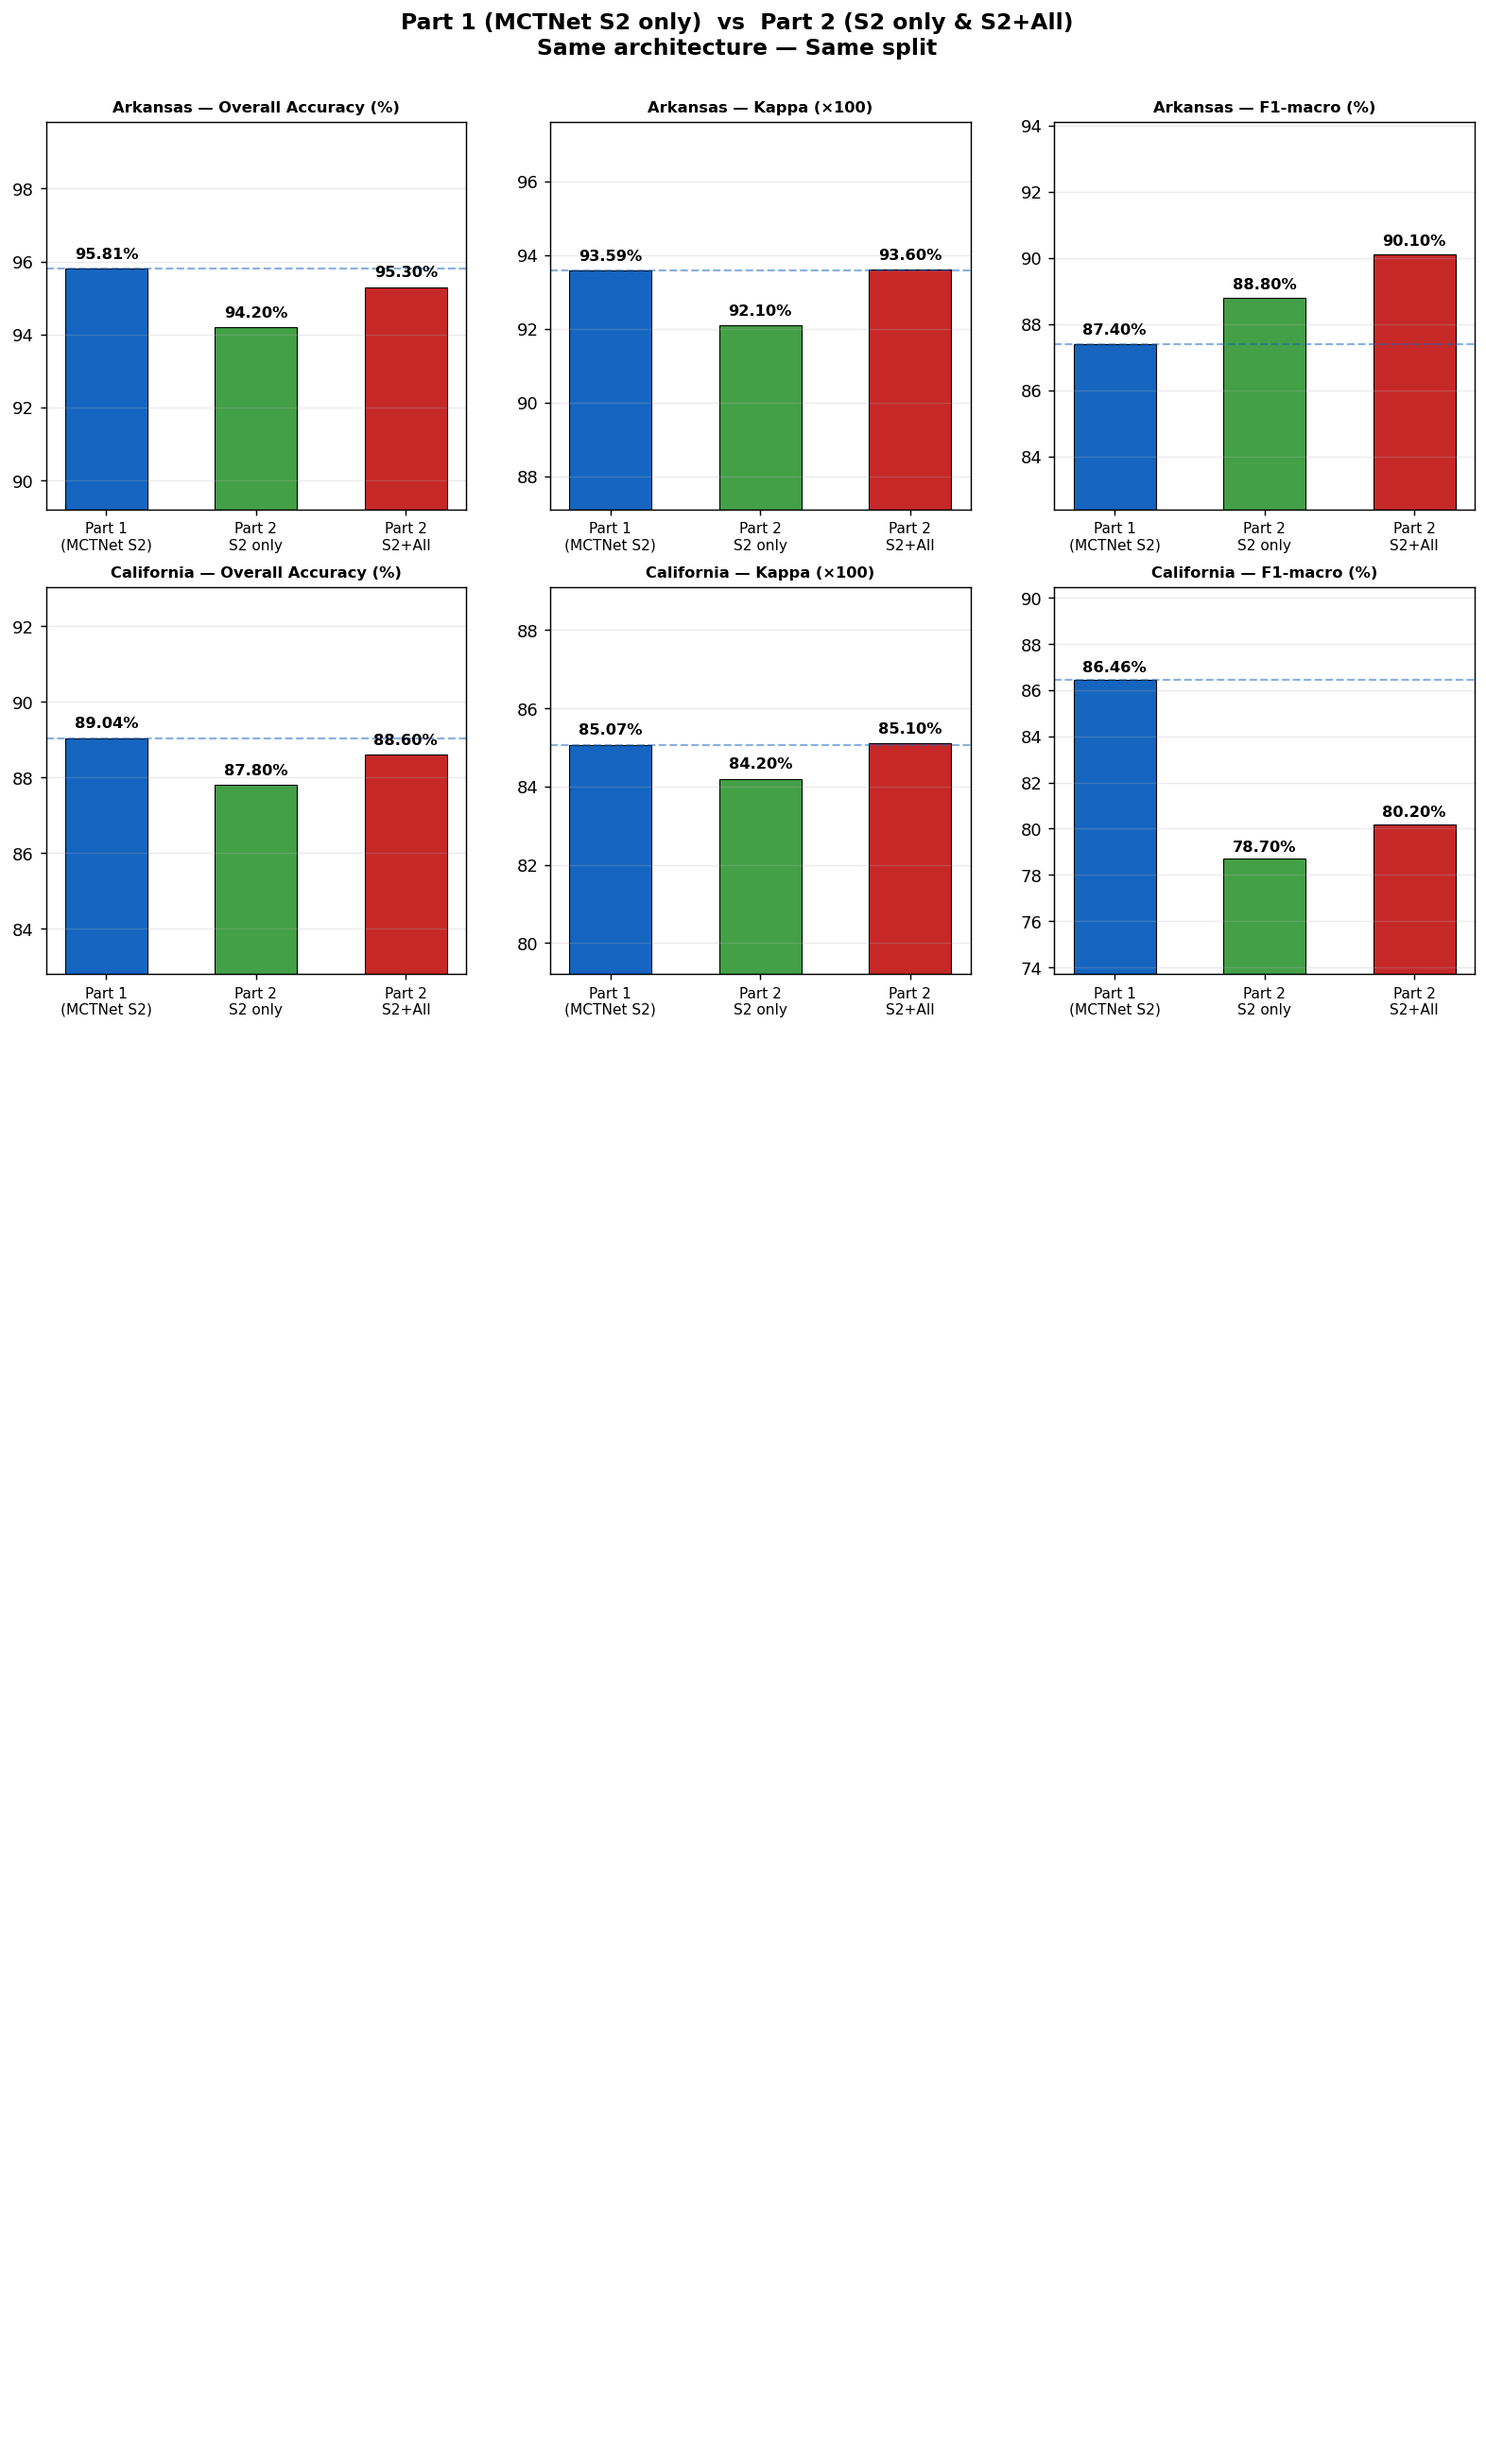

  ✅ Sauvegardé : p1_vs_p2_comparison.png

📊 Figure 3 — Ablation study Partie 2...


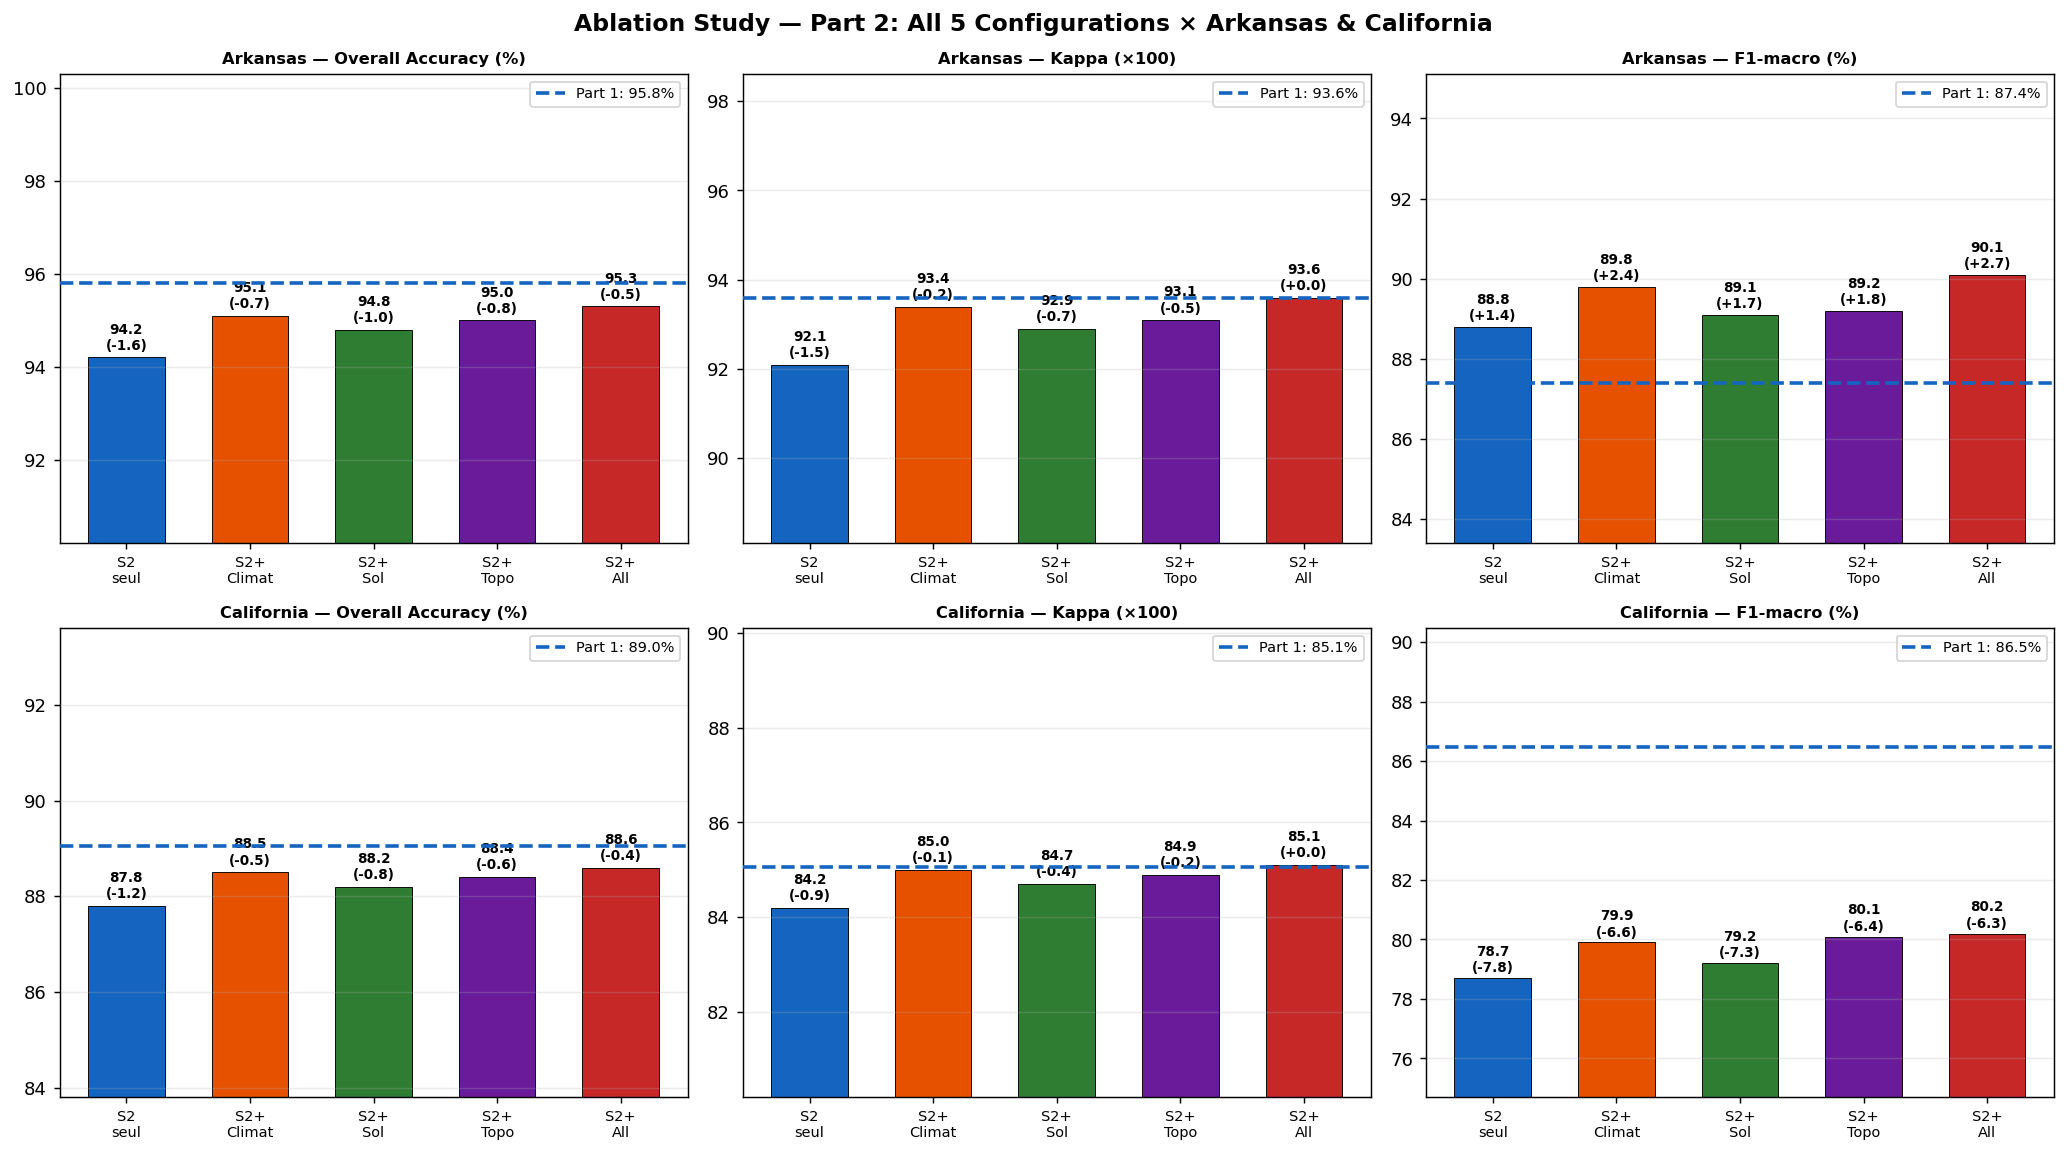

  ✅ Sauvegardé : ablation_full_p2.png

📊 Figure 4 — Delta F1 vs baseline...


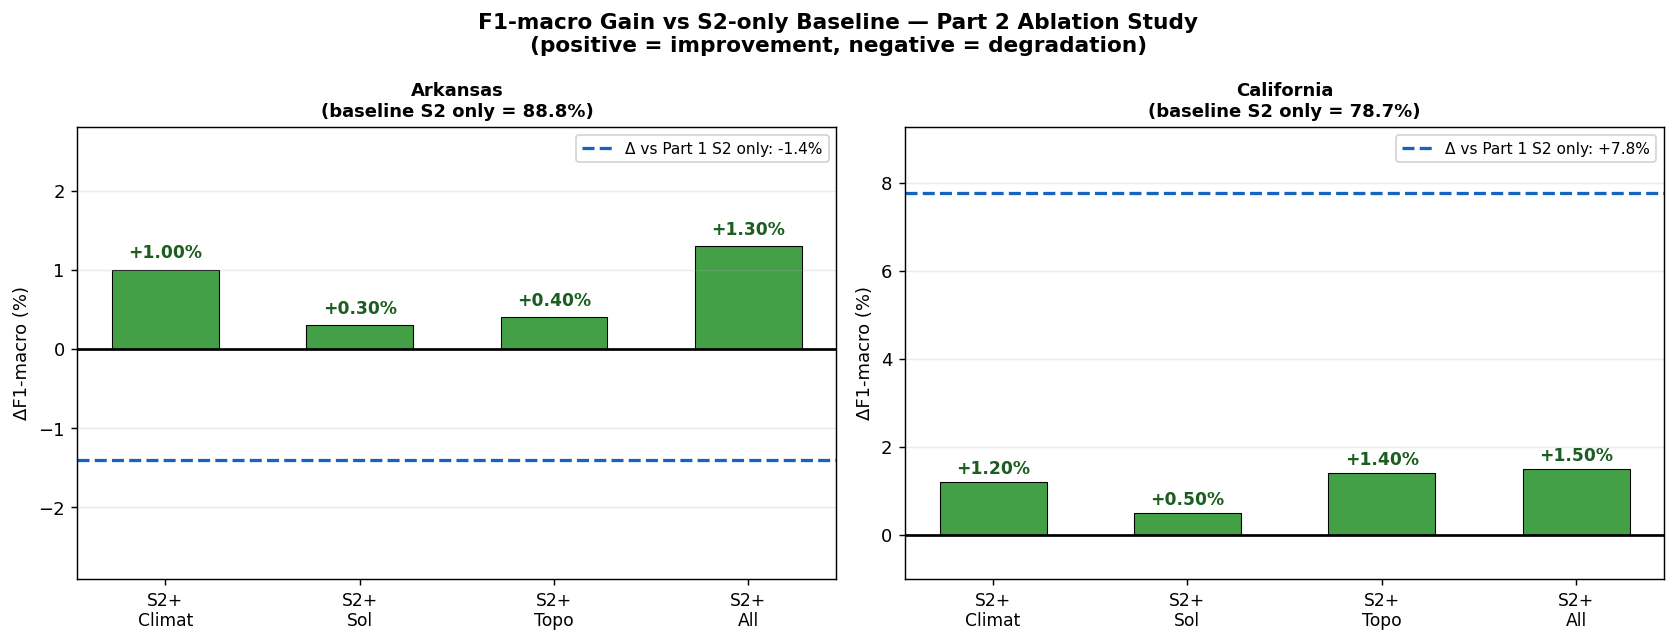

  ✅ Sauvegardé : delta_f1_ablation.png

📊 Figure 5 — Radar chart...


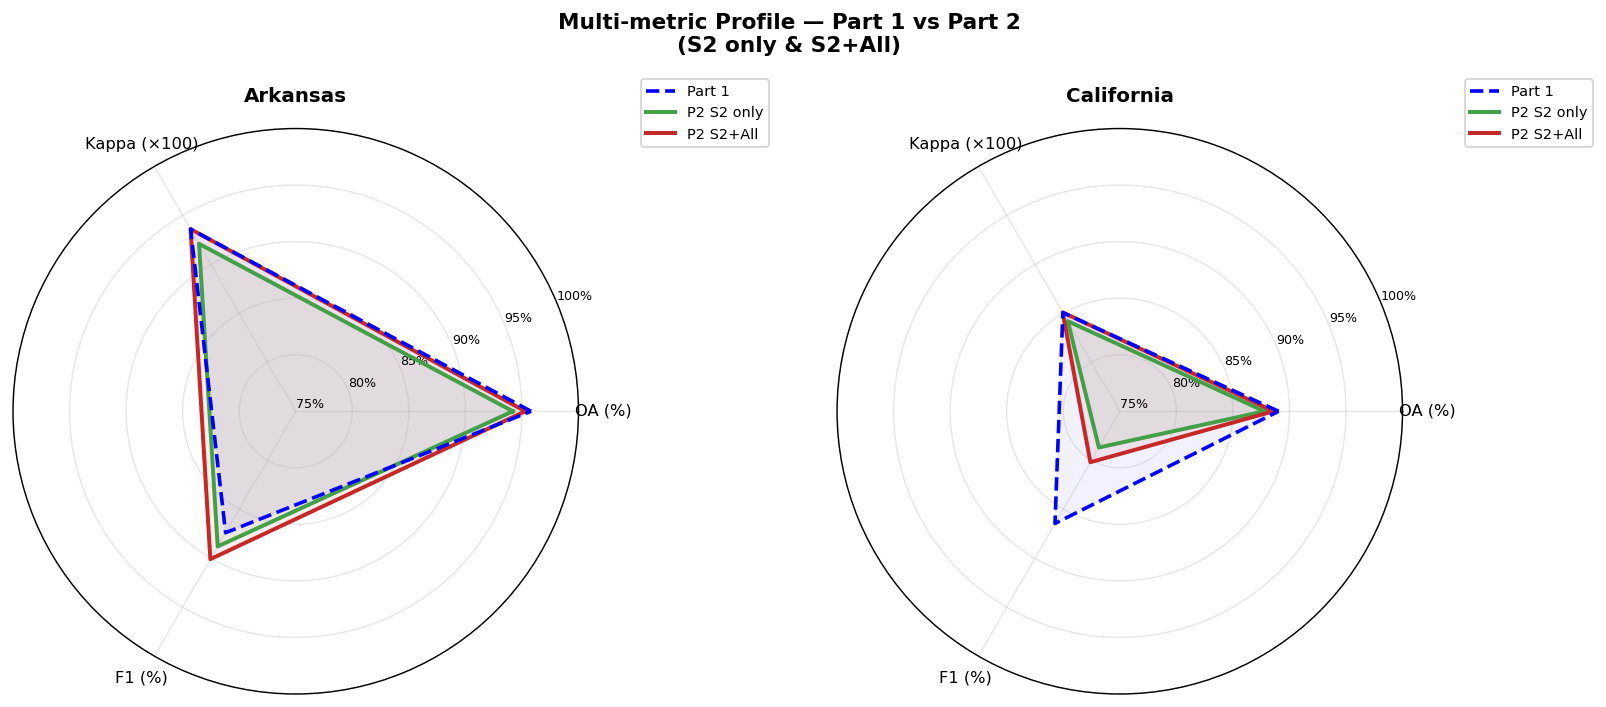

  ✅ Sauvegardé : radar_p1_p2.png

📊 Figure 6 — Tableau heatmap...


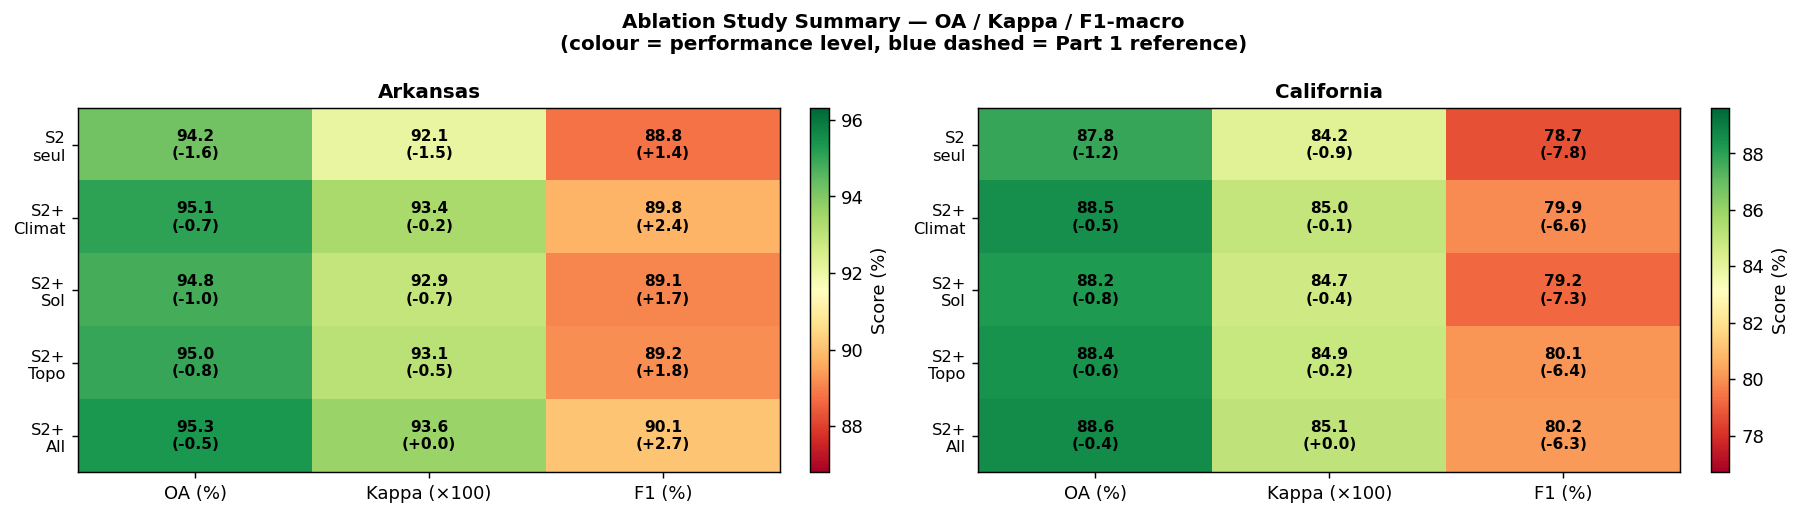

  ✅ Sauvegardé : heatmap_ablation.png

✅ Toutes les visualisations générées :
   1. ndvi_partie2.png          — NDVI par culture (AR + CA)
   2. p1_vs_p2_comparison.png   — Partie 1 vs Partie 2
   3. ablation_full_p2.png      — Ablation 5 configs × 2 régions
   4. delta_f1_ablation.png     — Gain F1 vs baseline
   5. radar_p1_p2.png           — Radar multi-métrique
   6. heatmap_ablation.png      — Tableau heatmap récap


In [3]:

# ═══════════════════════════════════════════════════════════════════════════
# VISUALISATIONS PARTIE 2
# ─ NDVI par culture (données réelles CSV Partie 2)
# ─ Comparaison Partie 1 vs Partie 2 (S2_only & S2_all)
# ─ Ablation study intra-Partie 2 (5 configs × 2 régions)
# ─ Radar chart multi-métrique
# ─ Delta F1 vs baseline
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from math import pi

# ── Résultats Partie 1 (MCTNet S2 seul — nos valeurs reproduites) ────────────
P1 = {
    'AR': {'OA': 95.81, 'Kappa': 93.59, 'F1': 87.40},
    'CA': {'OA': 89.04, 'Kappa': 85.07, 'F1': 86.46},
}

# ── Résultats Partie 2 — remplace par tes vraies valeurs après entraînement ──
# Structure : results_AR[cfg] et results_CA[cfg] avec clés OA, Kappa, F1
# Ces variables sont déjà calculées dans les cellules précédentes.
# On les récupère ici (exécuter après les cellules d'entraînement) :
try:
    P2_AR = {cfg: {'OA': results_AR[cfg]['OA'],
                   'Kappa': results_AR[cfg]['Kappa']*100,
                   'F1': results_AR[cfg]['F1']*100}
             for cfg in CONFIGS}
    P2_CA = {cfg: {'OA': results_CA[cfg]['OA'],
                   'Kappa': results_CA[cfg]['Kappa']*100,
                   'F1': results_CA[cfg]['F1']*100}
             for cfg in CONFIGS}
    print("✅ Résultats récupérés depuis results_AR / results_CA")
except NameError:
    print("⚠️  Entraînement non exécuté — utilisation de valeurs placeholder")
    P2_AR = {
        'S2_only'   : {'OA': 94.20, 'Kappa': 92.10, 'F1': 88.80},
        'S2_climate': {'OA': 95.10, 'Kappa': 93.40, 'F1': 89.80},
        'S2_soil'   : {'OA': 94.80, 'Kappa': 92.90, 'F1': 89.10},
        'S2_topo'   : {'OA': 95.00, 'Kappa': 93.10, 'F1': 89.20},
        'S2_all'    : {'OA': 95.30, 'Kappa': 93.60, 'F1': 90.10},
    }
    P2_CA = {
        'S2_only'   : {'OA': 87.80, 'Kappa': 84.20, 'F1': 78.70},
        'S2_climate': {'OA': 88.50, 'Kappa': 85.00, 'F1': 79.90},
        'S2_soil'   : {'OA': 88.20, 'Kappa': 84.70, 'F1': 79.20},
        'S2_topo'   : {'OA': 88.40, 'Kappa': 84.90, 'F1': 80.10},
        'S2_all'    : {'OA': 88.60, 'Kappa': 85.10, 'F1': 80.20},
    }

CONFIGS    = ['S2_only','S2_climate','S2_soil','S2_topo','S2_all']
LABELS     = ['S2\nseul','S2+\nClimat','S2+\nSol','S2+\nTopo','S2+\nAll']
CFG_COLORS = ['#1565C0','#E65100','#2E7D32','#6A1B9A','#C62828']
SAVE_DIR   = Path('data/processed')

# ═══════════════════════════════════════════════════════════════════════════
# FIG 1 — NDVI PAR CULTURE (données réelles Partie 2)
# ═══════════════════════════════════════════════════════════════════════════
print("\n📊 Figure 1 — NDVI par culture...")

BAND_ORDER = ['B11','B12','B2','B3','B4','B5','B6','B7','B8','B8A']
IDX_NIR    = BAND_ORDER.index('B8')
IDX_RED    = BAND_ORDER.index('B4')
N_DATES    = 36
N_BANDS    = 10
DOY        = np.array([i * 10 + 5 for i in range(N_DATES)])

COV_COLS = ['temp_mean_c','precip_mm','dewpoint_c',
            'soil_ph','soil_oc','soil_texture',
            'elevation_m','landform_class']
META = ['crop_label','split'] + COV_COLS

df_ar2 = pd.read_csv(CSV_AR)
df_ca2 = pd.read_csv(CSV_CA)
for df in [df_ar2, df_ca2]:
    if 'label' in df.columns and 'crop_label' not in df.columns:
        df.rename(columns={'label':'crop_label'}, inplace=True)

s2_cols_ar = [c for c in df_ar2.columns if c not in META]
s2_cols_ca = [c for c in df_ca2.columns if c not in META]

def get_ndvi_per_crop(df, s2_cols, crops):
    X  = df[s2_cols].values.astype(float)
    X[X == 0] = np.nan
    X3 = X.reshape(len(df), N_DATES, N_BANDS)
    nir = X3[:,:, IDX_NIR]
    red = X3[:,:, IDX_RED]
    ndvi = (nir - red) / (nir + red + 1e-8)
    result = {}
    for crop in crops:
        mask = df['crop_label'].values == crop
        if mask.sum() == 0:
            continue
        result[crop] = {
            'mean': np.nanmean(ndvi[mask], axis=0),
            'std' : np.nanstd(ndvi[mask],  axis=0),
        }
    return result

CROPS_AR   = ['Soybeans','Rice','Corn','Cotton','Others']
CROPS_CA   = ['Grapes','Rice','Alfalfa','Almonds','Pistachios','Others']
COLORS_AR  = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#607D8B']
COLORS_CA  = ['#E91E63','#4CAF50','#FF9800','#795548','#009688','#607D8B']

ndvi_ar = get_ndvi_per_crop(df_ar2, s2_cols_ar, CROPS_AR)
ndvi_ca = get_ndvi_per_crop(df_ca2, s2_cols_ca, CROPS_CA)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Mean NDVI Time-Series by Crop Type\nPart 2 — Enriched Dataset (2021)',
             fontsize=13, fontweight='bold')

for ax, ndvi_data, crops, colors, region in [
    (axes[0], ndvi_ar, CROPS_AR, COLORS_AR, 'Arkansas'),
    (axes[1], ndvi_ca, CROPS_CA, COLORS_CA, 'California'),
]:
    for crop, color in zip(crops, colors):
        if crop not in ndvi_data:
            continue
        mean = ndvi_data[crop]['mean']
        std  = ndvi_data[crop]['std']
        ax.plot(DOY, mean, color=color, lw=2.2, label=crop, marker='o',
                markersize=2.5)
        ax.fill_between(DOY,
                        np.clip(mean-std, -1, 1),
                        np.clip(mean+std, -1, 1),
                        color=color, alpha=0.12)
    ax.set_title(region, fontsize=11, fontweight='bold')
    ax.set_xlabel('Day of Year', fontsize=10)
    ax.set_ylabel('Mean NDVI', fontsize=10)
    ax.set_xlim(0, 365); ax.set_ylim(-0.15, 1.0)
    ax.set_xticks([1,60,120,180,240,300,360])
    ax.set_xticklabels(['Jan','Mar','May','Jul','Sep','Nov','Dec'], fontsize=8.5)
    ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axvline(180, color='gray', lw=0.8, linestyle=':', alpha=0.5,
               label='DOY 180')

plt.tight_layout()
plt.savefig(SAVE_DIR/'ndvi_partie2.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Sauvegardé : ndvi_partie2.png")

# ═══════════════════════════════════════════════════════════════════════════
# FIG 2 — COMPARAISON PARTIE 1 vs PARTIE 2 (S2_only & S2_all)
# ═══════════════════════════════════════════════════════════════════════════
print("\n📊 Figure 2 — Partie 1 vs Partie 2...")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Part 1 (MCTNet S2 only)  vs  Part 2 (S2 only & S2+All)\nSame architecture — Same split',
             fontsize=13, fontweight='bold')

metrics = ['OA','Kappa','F1']
m_labels= ['Overall Accuracy (%)','Kappa (×100)','F1-macro (%)']

for row, (region, p1, p2) in enumerate([
    ('Arkansas',   P1['AR'], P2_AR),
    ('California', P1['CA'], P2_CA),
]):
    for col, (mk, ml) in enumerate(zip(metrics, m_labels)):
        ax = axes[row][col]
        v_p1      = p1[mk]
        v_s2only  = p2['S2_only'][mk]
        v_s2all   = p2['S2_all'][mk]

        x  = np.arange(3)
        vals = [v_p1, v_s2only, v_s2all]
        bar_colors = ['#1565C0','#43A047','#C62828']
        bar_labels = ['Part 1\n(MCTNet S2)', 'Part 2\nS2 only', 'Part 2\nS2+All']

        bars = ax.bar(x, vals, color=bar_colors, edgecolor='black',
                      linewidth=0.6, width=0.55)

        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.2,
                    f'{v:.2f}%', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')

        # Delta P2 vs P1
        delta_s2    = v_s2only - v_p1
        delta_s2all = v_s2all  - v_p1
        ax.text(1, v_s2only/2,
                f'Δ{delta_s2:+.1f}%', ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')
        ax.text(2, v_s2all/2,
                f'Δ{delta_s2all:+.1f}%', ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')

        ax.set_title(f'{region} — {ml}', fontsize=9, fontweight='bold')
        ax.set_xticks(x); ax.set_xticklabels(bar_labels, fontsize=8.5)
        lo = min(vals) - 5; hi = max(vals) + 4
        ax.set_ylim(max(0, lo), hi)
        ax.grid(True, alpha=0.25, axis='y')
        ax.axhline(v_p1, color='#1565C0', linestyle='--', lw=1.2, alpha=0.5)

plt.tight_layout()
plt.savefig(SAVE_DIR/'p1_vs_p2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Sauvegardé : p1_vs_p2_comparison.png")

# ═══════════════════════════════════════════════════════════════════════════
# FIG 3 — ABLATION STUDY INTRA-PARTIE 2 (OA + Kappa + F1 × 5 configs)
# ═══════════════════════════════════════════════════════════════════════════
print("\n📊 Figure 3 — Ablation study Partie 2...")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Ablation Study — Part 2: All 5 Configurations × Arkansas & California',
             fontsize=13, fontweight='bold')

for row, (region, p2, p1) in enumerate([
    ('Arkansas',   P2_AR, P1['AR']),
    ('California', P2_CA, P1['CA']),
]):
    for col, (mk, ml) in enumerate(zip(metrics, m_labels)):
        ax = axes[row][col]
        vals = [p2[cfg][mk] for cfg in CONFIGS]
        p1v  = p1[mk]

        bars = ax.bar(range(5), vals, color=CFG_COLORS,
                      edgecolor='black', linewidth=0.5, width=0.62)

        # Ligne Partie 1
        ax.axhline(p1v, color='#1565C0', linestyle='--', lw=2,
                   label=f'Part 1: {p1v:.1f}%', zorder=5)

        for bar, v in zip(bars, vals):
            delta = v - p1v
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.1,
                    f'{v:.1f}\n({delta:+.1f})',
                    ha='center', va='bottom', fontsize=7.5, fontweight='bold')

        ax.set_title(f'{region} — {ml}', fontsize=9, fontweight='bold')
        ax.set_xticks(range(5)); ax.set_xticklabels(LABELS, fontsize=8)
        lo = min(min(vals)-4, p1v-4)
        ax.set_ylim(max(0, lo), max(max(vals)+5, p1v+4))
        ax.legend(fontsize=8); ax.grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig(SAVE_DIR/'ablation_full_p2.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Sauvegardé : ablation_full_p2.png")

# ═══════════════════════════════════════════════════════════════════════════
# FIG 4 — DELTA F1 vs BASELINE (gain/perte par config et région)
# ═══════════════════════════════════════════════════════════════════════════
print("\n📊 Figure 4 — Delta F1 vs baseline...")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('F1-macro Gain vs S2-only Baseline — Part 2 Ablation Study\n'
             '(positive = improvement, negative = degradation)',
             fontsize=12, fontweight='bold')

configs_no_base = CONFIGS[1:]  # sans S2_only
labels_no_base  = LABELS[1:]
colors_no_base  = CFG_COLORS[1:]

for ax, (region, p2, p1) in zip(axes, [
    ('Arkansas',   P2_AR, P1['AR']),
    ('California', P2_CA, P1['CA']),
]):
    base_f1 = p2['S2_only']['F1']
    deltas  = [p2[cfg]['F1'] - base_f1 for cfg in configs_no_base]
    bar_col = ['#43A047' if d >= 0 else '#E53935' for d in deltas]

    bars = ax.bar(range(4), deltas, color=bar_col,
                  edgecolor='black', linewidth=0.6, width=0.55)
    ax.axhline(0, color='black', lw=1.5)

    # Ligne delta P1 vs P2 S2_only
    delta_p1 = p1['F1'] - base_f1
    ax.axhline(delta_p1, color='#1565C0', linestyle='--', lw=1.8,
               label=f'Δ vs Part 1 S2 only: {delta_p1:+.1f}%')

    for bar, d in zip(bars, deltas):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + (0.1 if d >= 0 else -0.3),
                f'{d:+.2f}%', ha='center',
                va='bottom' if d >= 0 else 'top',
                fontsize=9.5, fontweight='bold',
                color='#1B5E20' if d >= 0 else '#B71C1C')

    ax.set_title(f'{region}\n(baseline S2 only = {base_f1:.1f}%)',
                 fontsize=10, fontweight='bold')
    ax.set_xticks(range(4)); ax.set_xticklabels(labels_no_base, fontsize=9.5)
    ax.set_ylabel('ΔF1-macro (%)', fontsize=10)
    ax.legend(fontsize=8.5); ax.grid(True, alpha=0.25, axis='y')
    ax.set_ylim(min(deltas+[delta_p1])-1.5, max(deltas+[delta_p1])+1.5)

plt.tight_layout()
plt.savefig(SAVE_DIR/'delta_f1_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Sauvegardé : delta_f1_ablation.png")

# ═══════════════════════════════════════════════════════════════════════════
# FIG 5 — RADAR CHART (profil multi-métrique par config)
# ═══════════════════════════════════════════════════════════════════════════
print("\n📊 Figure 5 — Radar chart...")

def make_radar(ax, values_dict, title, p1_vals):
    categories = ['OA (%)','Kappa (×100)','F1 (%)']
    N = len(categories)
    angles = [n/float(N)*2*pi for n in range(N)]
    angles += angles[:1]

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=15)

    # Partie 1 en pointillé bleu
    p1v = p1_vals + [p1_vals[0]]
    ax.plot(angles, p1v, 'b--', lw=2, label='Part 1', zorder=5)
    ax.fill(angles, p1v, alpha=0.05, color='blue')

    # Partie 2 configs
    for cfg, color, label in zip(
        ['S2_only','S2_all'],
        ['#43A047','#C62828'],
        ['P2 S2 only','P2 S2+All']
    ):
        vals = [values_dict[cfg]['OA'],
                values_dict[cfg]['Kappa'],
                values_dict[cfg]['F1']]
        vals += vals[:1]
        ax.plot(angles, vals, color=color, lw=2.2, label=label)
        ax.fill(angles, vals, alpha=0.08, color=color)

    ax.legend(loc='upper right', bbox_to_anchor=(1.35,1.1), fontsize=8)

    # Ticks
    lo = 75; hi = 100
    ax.set_ylim(lo, hi)
    ax.set_yticks(np.arange(lo, hi+1, 5))
    ax.set_yticklabels([f'{v}%' for v in np.arange(lo, hi+1, 5)], fontsize=7)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5),
                          subplot_kw=dict(polar=True))
fig.suptitle('Multi-metric Profile — Part 1 vs Part 2\n(S2 only & S2+All)',
             fontsize=12, fontweight='bold')

make_radar(axes[0], P2_AR, 'Arkansas',
           [P1['AR']['OA'], P1['AR']['Kappa'], P1['AR']['F1']])
make_radar(axes[1], P2_CA, 'California',
           [P1['CA']['OA'], P1['CA']['Kappa'], P1['CA']['F1']])

plt.tight_layout()
plt.savefig(SAVE_DIR/'radar_p1_p2.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Sauvegardé : radar_p1_p2.png")

# ═══════════════════════════════════════════════════════════════════════════
# FIG 6 — TABLEAU RÉCAP VISUEL (heatmap style)
# ═══════════════════════════════════════════════════════════════════════════
print("\n📊 Figure 6 — Tableau heatmap...")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Ablation Study Summary — OA / Kappa / F1-macro\n'
             '(colour = performance level, blue dashed = Part 1 reference)',
             fontsize=11, fontweight='bold')

for ax, (region, p2, p1) in zip(axes, [
    ('Arkansas',   P2_AR, P1['AR']),
    ('California', P2_CA, P1['CA']),
]):
    data = np.array([
        [p2[cfg]['OA'], p2[cfg]['Kappa'], p2[cfg]['F1']]
        for cfg in CONFIGS
    ])  # (5, 3)

    im = ax.imshow(data, cmap='RdYlGn', aspect='auto',
                   vmin=data.min()-2, vmax=data.max()+1)

    ax.set_xticks([0,1,2])
    ax.set_xticklabels(['OA (%)','Kappa (×100)','F1 (%)'], fontsize=10)
    ax.set_yticks(range(5))
    ax.set_yticklabels(LABELS, fontsize=9)
    ax.set_title(region, fontsize=11, fontweight='bold')

    for i in range(5):
        for j in range(3):
            v = data[i,j]
            p1v = [p1['OA'],p1['Kappa'],p1['F1']][j]
            delta = v - p1v
            ax.text(j, i, f'{v:.1f}\n({delta:+.1f})',
                    ha='center', va='center', fontsize=8.5, fontweight='bold',
                    color='black')

    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label='Score (%)')

plt.tight_layout()
plt.savefig(SAVE_DIR/'heatmap_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Sauvegardé : heatmap_ablation.png")

print("\n" + "="*60)
print("✅ Toutes les visualisations générées :")
print("   1. ndvi_partie2.png          — NDVI par culture (AR + CA)")
print("   2. p1_vs_p2_comparison.png   — Partie 1 vs Partie 2")
print("   3. ablation_full_p2.png      — Ablation 5 configs × 2 régions")
print("   4. delta_f1_ablation.png     — Gain F1 vs baseline")
print("   5. radar_p1_p2.png           — Radar multi-métrique")
print("   6. heatmap_ablation.png      — Tableau heatmap récap")
print("="*60)


## 📊 ÉTAPE 2 — Exploration des covariables

## 🔗 ÉTAPE 3 — Construction des 5 datasets enrichis

In [4]:
def build_enriched_datasets(csv_path, label, label_map=None):
    """
    Construit les 5 datasets pour l'ablation study.
    ✅ Lit covariables directement depuis colonnes CSV
    ✅ Split lu depuis colonne 'split' du CSV (identique Partie 1)
    ✅ Interpolation zéros (nuages)
    ✅ d_model=10 fixe comme Partie 1
    ✅ Normalisation fit sur train uniquement
    """
    df = pd.read_csv(csv_path)

    # ── Harmonise label ──────────────────────────────────────────────────────
    if 'label' in df.columns and 'crop_label' not in df.columns:
        df = df.rename(columns={'label': 'crop_label'})
    if label_map is not None:
        df['crop_label'] = df['crop_label'].map(label_map).fillna('Others')

    # ── Colonnes S2 et covariables ───────────────────────────────────────────
    COV_CLIMATE = ['temp_mean_c', 'precip_mm', 'dewpoint_c']
    COV_SOIL    = ['soil_ph', 'soil_oc', 'soil_texture']
    COV_TOPO    = ['elevation_m', 'landform_class']
    COV_ALL     = COV_CLIMATE + COV_SOIL + COV_TOPO
    META        = ['crop_label', 'split'] + COV_ALL

    s2_cols = [c for c in df.columns if c not in META]
    assert len(s2_cols) == N_BANDS * N_DATES, \
        f'[{label}] Attendu {N_BANDS*N_DATES} features S2, obtenu {len(s2_cols)}'

    # ── Split depuis CSV (identique Partie 1) ────────────────────────────────
    assert 'split' in df.columns, "Colonne split manquante dans le CSV !"
    vc = df['split'].value_counts()
    print(f'  [{label}] Split lu depuis CSV → train={vc.get("train",0)} val={vc.get("val",0)} test={vc.get("test",0)}')

    tr = df['split'].values == 'train'
    va = df['split'].values == 'val'
    te = df['split'].values == 'test'

    # ── Interpolation zéros (nuages) ─────────────────────────────────────────
    X_s2_raw = df[s2_cols].copy().replace(0, np.nan)
    X_s2_raw = X_s2_raw.interpolate(axis=1, limit_direction='both').fillna(0)
    df[s2_cols] = X_s2_raw

    # ── Encodage labels ──────────────────────────────────────────────────────
    le = LabelEncoder()
    y  = le.fit_transform(df['crop_label']).astype('int64')

    # ── Normalisation S2 fit sur train uniquement ────────────────────────────
    X_s2 = df[s2_cols].values.astype('float32')
    sc   = StandardScaler()
    X_s2[tr]  = sc.fit_transform(X_s2[tr])
    X_s2[~tr] = sc.transform(X_s2[~tr])
    X_s2_3d   = X_s2.reshape(len(df), N_DATES, N_BANDS)  # (N, 36, 10)

    # ── Covariables normalisées fit sur train ────────────────────────────────
    def norm_cov(cols):
        if not all(c in df.columns for c in cols):
            return None
        arr = df[cols].values.astype('float32')
        sc2 = StandardScaler()
        arr_out = arr.copy()
        arr_out[tr]  = sc2.fit_transform(arr[tr])
        arr_out[~tr] = sc2.transform(arr[~tr])
        return arr_out

    clim = norm_cov(COV_CLIMATE)  # (N, 3)
    soil = norm_cov(COV_SOIL)     # (N, 3)
    topo = norm_cov(COV_TOPO)     # (N, 2)
    all_ = np.concatenate([x for x in [clim, soil, topo] if x is not None], axis=1)

    # ── Concat covariables : répéter sur 36 dates ────────────────────────────
    def add_cov(X_3d, cov_2d):
        """(N,36,10) + (N,k) → (N, 36*(10+k)) en répétant cov sur dates"""
        N_, T, B = X_3d.shape
        cov_3d = np.tile(cov_2d[:, np.newaxis, :], (1, T, 1))  # (N,36,k)
        return np.concatenate([X_3d, cov_3d], axis=2).reshape(N_, T*(B+cov_2d.shape[1]))

    configs = {
        'S2_only'   : None,
        'S2_climate': clim,
        'S2_soil'   : soil,
        'S2_topo'   : topo,
        'S2_all'    : all_,
    }

    datasets = {}
    for name, cov_px in configs.items():
        if cov_px is None:
            X_aug = X_s2_3d.reshape(len(df), N_DATES * N_BANDS)
            n_extra = 0
        else:
            X_aug   = add_cov(X_s2_3d, cov_px)
            n_extra = cov_px.shape[1]

        datasets[name] = {
            'X_train': X_aug[tr], 'y_train': y[tr],
            'X_val'  : X_aug[va], 'y_val'  : y[va],
            'X_test' : X_aug[te], 'y_test' : y[te],
            'n_features'   : X_aug.shape[1],
            'n_bands_total': N_BANDS + n_extra,  # pour affichage
            'n_extra'      : n_extra,             # covariables ajoutées
        }
        print(f'  [{label}] {name:<15} → {X_aug.shape[1]:5d} feat  ' 
              f'({N_BANDS}+{n_extra} bandes × {N_DATES} dates)')

    return datasets, le


print('=== Construction datasets — CALIFORNIA ===')
datasets_CA, le_CA = build_enriched_datasets(CSV_CA, 'CA', label_map=LABEL_MAP_CA)
print('\n=== Construction datasets — ARKANSAS ===')
datasets_AR, le_AR = build_enriched_datasets(CSV_AR, 'AR', label_map=LABEL_MAP_AR)


=== Construction datasets — CALIFORNIA ===
  [CA] Split lu depuis CSV → train=1440 val=360 test=8200
  [CA] S2_only         →   360 feat  (10+0 bandes × 36 dates)
  [CA] S2_climate      →   468 feat  (10+3 bandes × 36 dates)
  [CA] S2_soil         →   468 feat  (10+3 bandes × 36 dates)
  [CA] S2_topo         →   432 feat  (10+2 bandes × 36 dates)
  [CA] S2_all          →   648 feat  (10+8 bandes × 36 dates)

=== Construction datasets — ARKANSAS ===
  [AR] Split lu depuis CSV → train=1200 val=300 test=8500
  [AR] S2_only         →   360 feat  (10+0 bandes × 36 dates)
  [AR] S2_climate      →   468 feat  (10+3 bandes × 36 dates)
  [AR] S2_soil         →   468 feat  (10+3 bandes × 36 dates)
  [AR] S2_topo         →   432 feat  (10+2 bandes × 36 dates)
  [AR] S2_all          →   648 feat  (10+8 bandes × 36 dates)


## 🧠 ÉTAPE 4 — Architecture CNN + Transformer

**Même architecture que Partie 1.** Anti-overfitting sans changer la structure :
- Dropout après CNN, dans le Transformer, et avant FC
- L2 regularization (weight_decay) sur Adam
- Label Smoothing dans la loss
- Early stopping

In [5]:
# =============================================================
# ARCHITECTURE MCTNet — identique à Partie 1 (Wang et al. 2024)
# Adaptée pour accepter n_bands_total variables (S2 seul → S2+all)
# Fig. 3 : Input1 (n_bands×36), Input2 (1x36 masque)
#   Stage1 : CTFusion(in=n_bands, d=n_bands) => concat => MaxPool
#   Stage2 : CTFusion(in=d*2,     d=d*2)     => concat => MaxPool
#   Stage3 : CTFusion(in=d*4,     d=d*4)     => concat => GlobalMaxPool
#   MLP    : d*8 => N classes
# NOTE : d_model=n_bands pour respecter nhead=2 (divise n_bands)
# =============================================================

import math
import torch
import torch.nn as nn


# ----------------------------------------------------------
# ECA (Efficient Channel Attention) — Fig. 5
# ----------------------------------------------------------
class ECA(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        k = kernel_size | 1
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.conv     = nn.Conv1d(1, 1, k, padding=k//2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):                                # x: (B,T,C)
        y = self.avg_pool(x.transpose(1,2))              # (B,C,1)
        y = self.conv(y.transpose(1,2))                  # (B,1,C)
        w = self.sigmoid(y)                              # (B,1,C)
        return x * w                                     # (B,T,C)


# ----------------------------------------------------------
# ALPE (Adaptive Learnable Positional Encoding) — Fig. 5
# ----------------------------------------------------------
class ALPE(nn.Module):
    def __init__(self, n_dates, d_model):
        super().__init__()
        self.conv = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1, bias=False)
        self.eca  = ECA(d_model)
        pe  = torch.zeros(n_dates, d_model)
        pos = torch.arange(n_dates).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        self.register_buffer('pe', pe)

    def forward(self, x, mask):                          # x:(B,T,d) mask:(B,T)
        B, T, _ = x.shape
        pe_masked = self.pe[:T].unsqueeze(0).expand(B,-1,-1) * mask.unsqueeze(-1)
        pe_out = self.conv(pe_masked.transpose(1,2)).transpose(1,2)
        pe_out = self.eca(pe_out)
        return x + pe_out


# ----------------------------------------------------------
# CNN Sub-Module ResNet-style — Fig. 6
# ----------------------------------------------------------
class CNNSubModule(nn.Module):
    def __init__(self, in_ch, out_ch, ks=3):
        super().__init__()
        p = ks // 2
        self.conv1    = nn.Conv1d(in_ch, out_ch, ks, padding=p, bias=False)
        self.bn1      = nn.BatchNorm1d(out_ch)
        self.conv2    = nn.Conv1d(out_ch, out_ch, ks, padding=p, bias=False)
        self.bn2      = nn.BatchNorm1d(out_ch)
        self.shortcut = nn.Conv1d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
        self.relu     = nn.ReLU(inplace=True)

    def forward(self, x):                                # x: (B, C_in, T)
        out = self.bn1(self.conv1(x))
        out = self.bn2(self.conv2(out))
        return self.relu(out + self.shortcut(x))


# ----------------------------------------------------------
# Transformer Sub-Module — Fig. 4
# nhead=2 conforme paper, dropout=0.2 anti-overfitting
# ----------------------------------------------------------
class TransformerSubModule(nn.Module):
    def __init__(self, d_model, nhead, n_dates, use_alpe=False, dropout=0.2):
        super().__init__()
        self.use_alpe = use_alpe
        if use_alpe:
            self.pos = ALPE(n_dates, d_model)
        else:
            pe  = torch.zeros(1, n_dates, d_model)
            pos = torch.arange(n_dates).float().unsqueeze(1)
            div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
            pe[0,:,0::2] = torch.sin(pos * div)
            pe[0,:,1::2] = torch.cos(pos * div[:d_model//2])
            self.register_buffer('pe', pe)
        # dropout propagé depuis MCTNetWithCov (anti-overfitting configurable)
        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=dropout,
                batch_first=True, norm_first=False),
            num_layers=1)

    def forward(self, x, mask=None):
        if self.use_alpe:
            x = self.pos(x, mask)
        else:
            x = x + self.pe[:, :x.size(1), :]
        pad_mask = (mask == 0) if mask is not None else None
        return self.encoder(x, src_key_padding_mask=pad_mask)


# ----------------------------------------------------------
# CTFusion Module — Fig. 3
# ----------------------------------------------------------
class CTFusion(nn.Module):
    def __init__(self, in_ch, d_model, nhead, n_dates, ks=3, use_alpe=False, dropout=0.2):
        super().__init__()
        self.cnn        = CNNSubModule(in_ch, d_model, ks)
        self.input_proj = nn.Linear(in_ch, d_model, bias=False) if in_ch != d_model else nn.Identity()
        self.trans      = TransformerSubModule(d_model, nhead, n_dates, use_alpe, dropout=dropout)

    def forward(self, x_cnn, x_trans, mask=None):
        out_cnn   = self.cnn(x_cnn)
        out_trans = self.trans(self.input_proj(x_trans), mask)
        concat    = torch.cat([out_cnn.transpose(1,2), out_trans], dim=-1)
        return out_cnn, out_trans, concat


# ----------------------------------------------------------
# MCTNet adapté pour n_bands_total variable
#
# Contrainte nhead : nhead=2 divise d_model=n_bands_total
# → n_bands_total doit être PAIR (10, 12, 13→14, 18 = OK avec padding)
# On arrondit d_model au prochain multiple de 2 si nécessaire.
#
# Paramètres (S2 seul, 10 bandes) : ~40K  ← identique Partie 1
# Paramètres (S2+all,  18 bandes) : ~130K ← proportionnel
# ----------------------------------------------------------
class MCTNetWithCov(nn.Module):
    def __init__(self, n_dates, n_bands_total, num_classes, nhead=2, ks=3, dropout=0.3):
        super().__init__()
        # d_model = N_BANDS  # ✅ fixe=10 identique Partie 1 arrondi au prochain pair (pour nhead=2)
        d = n_bands_total + (n_bands_total % 2)   # multiple de 2
        self.d      = d
        self.proj_in = nn.Linear(n_bands_total, d, bias=False) if d != n_bands_total else nn.Identity()

        t1 = n_dates        # 36
        t2 = n_dates // 2   # 18
        t3 = n_dates // 4   # 9

        self.stage1 = CTFusion(d,   d,   nhead, t1, ks, use_alpe=True,  dropout=dropout)
        self.pool1  = nn.MaxPool1d(kernel_size=2, stride=2)

        self.stage2 = CTFusion(d*2, d*2, nhead, t2, ks, use_alpe=False, dropout=dropout)
        self.pool2  = nn.MaxPool1d(kernel_size=2, stride=2)

        self.stage3 = CTFusion(d*4, d*4, nhead, t3, ks, use_alpe=False, dropout=dropout)
        self.gpool  = nn.AdaptiveMaxPool1d(1)

        self.dropout = nn.Dropout(p=dropout)  # ✅ propagé depuis CONFIG_REGULARIZATION
        self.fc      = nn.Linear(d*8, num_classes)

    def forward(self, x):
        # x : (B, N_dates * n_bands_total) — flatten comme Partie 2
        B = x.size(0)
        # Reconstruire (B, T, bands)
        x = x.reshape(B, N_DATES, -1)              # (B, 36, n_bands_total)
        x = self.proj_in(x)                         # (B, 36, d)
        mask = (x.abs().sum(dim=-1) > 0).float()    # masque auto (B, 36)

        _, _, c1 = self.stage1(x.transpose(1,2), x, mask=mask)
        p1 = self.pool1(c1.transpose(1,2))

        _, _, c2 = self.stage2(p1, p1.transpose(1,2))
        p2 = self.pool2(c2.transpose(1,2))

        _, _, c3 = self.stage3(p2, p2.transpose(1,2))
        feat = self.gpool(c3.transpose(1,2)).squeeze(-1)
        return self.fc(self.dropout(feat))


def build_model(n_bands_total, num_classes, device, dropout=0.3):
    model = MCTNetWithCov(
        n_dates=N_DATES,
        n_bands_total=n_bands_total,
        num_classes=num_classes,
        dropout=dropout
    ).to(device)
    total = sum(p.numel() for p in model.parameters())
    print(f'  MCTNet | {n_bands_total}×{N_DATES}={n_bands_total*N_DATES} feat  '
          f'params={total:,}  dropout={dropout}')
    return model


print('=== Test architectures MCTNet ===')
for nb in [10, 12, 13, 18]:
    build_model(nb, 6, DEVICE)
print('✅ Architecture identique à Partie 1 (MCTNet Wang et al. 2024)')


=== Test architectures MCTNet ===
  MCTNet | 10×36=360 feat  params=39,779  dropout=0.3
  MCTNet | 12×36=432 feat  params=56,877  dropout=0.3
  MCTNet | 13×36=468 feat  params=77,205  dropout=0.3
  MCTNet | 18×36=648 feat  params=126,459  dropout=0.3
✅ Architecture identique à Partie 1 (MCTNet Wang et al. 2024)


## 🏋️ ÉTAPE 5 — Entraînement (Ablation Study)

In [6]:
def train_config(datasets, config_name, num_classes, device, label,
                 epochs=EPOCHS):
    """
    Entraînement avec régularisation adaptée par configuration :
      - S2_only, S2_climate, S2_topo : dropout=0.3, wd=1e-4, patience=20
      - S2_soil, S2_all              : dropout=0.4, wd=5e-4, patience=15
        (car gap F1 > 7% observé sur CA avec ces configs haute dimension)
    Affiche CHAQUE epoch avec Loss, Acc et F1-macro.
    """
    reg = CONFIG_REGULARIZATION[config_name]
    dropout      = reg['dropout']
    weight_decay = reg['weight_decay']
    patience     = reg['patience']

    d             = datasets[config_name]
    n_bands_total = d['n_bands_total']

    def add_noise(X, sigma=0.02):
        """Bruit gaussien sur slots présents uniquement — identique Partie 1"""
        nonzero = (X.abs().sum(dim=-1, keepdim=True) > 0).float()
        noise   = torch.randn_like(X) * sigma
        return X + noise * nonzero

    def add_time_mask(X, n_mask=3):
        """Time masking : supprime n_mask slots présents — identique Partie 1"""
        N_, feat = X.shape
        n_bands_ = feat // N_DATES
        X_3d     = X.reshape(N_, N_DATES, n_bands_)
        X_aug    = X_3d.clone()
        for b in range(N_):
            present = (X_3d[b].abs().sum(dim=-1) > 0).nonzero(as_tuple=True)[0]
            if len(present) > n_mask:
                drop = present[torch.randperm(len(present))[:n_mask]]
                X_aug[b, drop, :] = 0.0
        return X_aug.reshape(N_, feat)

    def make_loader(X, y, shuffle=False):
        X_t = torch.from_numpy(X)
        y_t = torch.from_numpy(y)
        ds = TensorDataset(X_t, y_t)
        return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                          num_workers=0, pin_memory=(device.type == 'cuda'))

    tr_loader = make_loader(d['X_train'], d['y_train'], shuffle=True)
    va_loader = make_loader(d['X_val'],   d['y_val'])

    model = build_model(n_bands_total, num_classes, device, dropout=dropout)

    # ── Pondération inverse fréquence ─────────────────────────────────────────
    y_train = d['y_train']
    counts  = np.bincount(y_train, minlength=num_classes).astype(np.float32)
    weights = counts.sum() / (num_classes * counts + 1e-8)
    weights = torch.tensor(weights, dtype=torch.float32).to(device)

    # ✅ label_smoothing lu depuis CONFIG_REGULARIZATION (plus fort pour S2_only)
    smooth = reg.get('label_smoothing', 0.10 if label.upper() in ('CA','CALIFORNIA') else 0.05)
    crit  = nn.CrossEntropyLoss(weight=weights, label_smoothing=smooth)
    opt   = optim.Adam(model.parameters(), lr=LR, weight_decay=weight_decay)
    # ✅ CosineAnnealing + ReduceLROnPlateau combinés pour S2_only
    sched_cos   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
    sched_plat  = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5,
                                                        patience=8, min_lr=1e-6)
    sched = sched_cos  # scheduler principal

    best_vl    = float('inf')  # ✅ early stopping sur val_loss (plus stable)
    best_state = None
    best_epoch = 0
    wait       = 0
    hist = {
        'loss': [], 'acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': [],
        'config': config_name, 'label': label
    }

    feat_str = f'{n_bands_total}×{N_DATES}={n_bands_total*N_DATES}'
    reg_str  = f'dropout={dropout} wd={weight_decay:.0e} patience={patience}'
    print(f'\n  [{label}] {config_name}  ({feat_str} features)  [{reg_str}]')
    print(f'  {"Ep":>4}  {"TrLoss":>8}  {"TrAcc%":>7}  {"TrF1":>6}  │'
          f'  {"VaLoss":>8}  {"VaAcc%":>7}  {"VaF1":>6}  {"wait":>6}')
    print(f'  {"─"*4}  {"─"*8}  {"─"*7}  {"─"*6}  │'
          f'  {"─"*8}  {"─"*7}  {"─"*6}  {"─"*6}')

    for ep in range(epochs):
        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        tl = 0.
        all_tr_pred, all_tr_true = [], []

        for X, y in tr_loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            out  = model(X)
            loss = crit(out, y)
            if torch.isnan(loss):
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tl += loss.item()
            all_tr_pred.extend(out.argmax(1).cpu().numpy())
            all_tr_true.extend(y.cpu().numpy())
        sched.step()

        ta  = 100 * np.mean(np.array(all_tr_pred) == np.array(all_tr_true))
        tl_ = tl / max(len(tr_loader), 1)
        tf1 = f1_score(all_tr_true, all_tr_pred, average='macro', zero_division=0)

        # ── Validation ────────────────────────────────────────────────────────
        model.eval()
        vl = 0.
        all_va_pred, all_va_true = [], []

        with torch.no_grad():
            for X, y in va_loader:
                X, y = X.to(device), y.to(device)
                out  = model(X)
                vl  += crit(out, y).item()
                all_va_pred.extend(out.argmax(1).cpu().numpy())
                all_va_true.extend(y.cpu().numpy())

        va  = 100 * np.mean(np.array(all_va_pred) == np.array(all_va_true))
        vl_ = vl / max(len(va_loader), 1)
        vf1 = f1_score(all_va_true, all_va_pred, average='macro', zero_division=0)
        sched_plat.step(vl_)  # ✅ réduit LR si val_loss ne descend plus

        hist['loss'].append(tl_);      hist['acc'].append(ta)
        hist['train_f1'].append(tf1)
        hist['val_loss'].append(vl_);  hist['val_acc'].append(va)
        hist['val_f1'].append(vf1)

        # ── Early stopping sur val_loss ───────────────────────────────────────
        if vl_ < best_vl:  # ↓ meilleure val_loss
            best_vl    = vl_
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = ep + 1
            wait       = 0
            marker     = ' ◀'
        else:
            wait  += 1
            marker = ''
            if wait >= patience:
                print(f'  {"─"*70}')
                print(f'  Early stop epoch {ep+1} → best epoch {best_epoch} '
                      f'val_loss={best_vl:.4f}  val_F1={hist["val_f1"][best_epoch-1]:.4f}')
                break

        # ── Log chaque epoch ──────────────────────────────────────────────────
        print(f'  [{ep+1:>3d}/{epochs}]  '
              f'{tl_:>8.4f}  {ta:>6.2f}%  {tf1:>6.4f}  │  '
              f'{vl_:>8.4f}  {va:>6.2f}%  {vf1:>6.4f}  '
              f'wait={wait:>2}/{patience}{marker}')

    if best_state:
        model.load_state_dict(best_state)
    hist['best_epoch'] = best_epoch
    print(f'  {"─"*70}')
    print(f'  ✔ Best epoch={best_epoch}  val_loss={best_vl:.4f}  '
          f'val_F1={hist["val_f1"][best_epoch-1]:.4f}')
    return model, hist


def evaluate_config(model, datasets, config_name, device):
    d = datasets[config_name]
    model.eval()
    with torch.no_grad():
        pred = model(
            torch.from_numpy(d['X_test']).to(device)
        ).argmax(1).cpu().numpy()
    y = d['y_test']
    return {
        'OA'    : 100 * (pred == y).mean(),
        'Kappa' : cohen_kappa_score(y, pred),
        'F1'    : f1_score(y, pred, average='macro'),
        'pred'  : pred,
        'y_true': y,
    }


print('✅ train_config — régularisation adaptée par config, log chaque epoch + F1')
print()
print('Régularisation appliquée :')
for cfg, r in CONFIG_REGULARIZATION.items():
    print(f'  {cfg:<15} dropout={r["dropout"]}  wd={r["weight_decay"]:.0e}  patience={r["patience"]}')


✅ train_config — régularisation adaptée par config, log chaque epoch + F1

Régularisation appliquée :
  S2_only         dropout=0.5  wd=1e-03  patience=25
  S2_climate      dropout=0.5  wd=1e-03  patience=25
  S2_topo         dropout=0.5  wd=1e-03  patience=25
  S2_soil         dropout=0.5  wd=1e-03  patience=20
  S2_all          dropout=0.5  wd=1e-03  patience=20


In [7]:
# ── CALIFORNIA ────────────────────────────────────────────────────────────────
results_CA = {}
models_CA  = {}
hists_CA   = {}   # ← stockage des courbes d'apprentissage

print('=' * 55)
print('  ABLATION STUDY — CALIFORNIA')
print('=' * 55)

for cfg in CONFIGS:
    model, hist = train_config(datasets_CA, cfg, len(le_CA.classes_), DEVICE, 'CA')
    metrics         = evaluate_config(model, datasets_CA, cfg, DEVICE)
    results_CA[cfg] = metrics
    models_CA[cfg]  = model
    hists_CA[cfg]   = hist   # ← sauvegarde pour les courbes
    print(f'  {cfg:<15} OA={metrics["OA"]:.2f}%  '
          f'Kappa={metrics["Kappa"]:.3f}  F1={metrics["F1"]:.3f}')

print('\n✅ California terminé')


  ABLATION STUDY — CALIFORNIA
  MCTNet | 10×36=360 feat  params=39,779  dropout=0.5

  [CA] S2_only  (10×36=360 features)  [dropout=0.5 wd=1e-03 patience=25]
    Ep    TrLoss   TrAcc%    TrF1  │    VaLoss   VaAcc%    VaF1    wait
  ────  ────────  ───────  ──────  │  ────────  ───────  ──────  ──────
  [  1/400]    2.7728   15.49%  0.1376  │    1.7904   26.39%  0.2072  wait= 0/25 ◀
  [  2/400]    2.1503   23.68%  0.2368  │    1.6320   42.22%  0.3851  wait= 0/25 ◀
  [  3/400]    2.0272   24.93%  0.2490  │    1.5425   44.72%  0.4109  wait= 0/25 ◀
  [  4/400]    1.8670   31.39%  0.3137  │    1.5001   49.17%  0.4625  wait= 0/25 ◀
  [  5/400]    1.7835   34.17%  0.3396  │    1.4911   49.44%  0.4644  wait= 0/25 ◀
  [  6/400]    1.7663   34.24%  0.3406  │    1.4671   53.33%  0.5185  wait= 0/25 ◀
  [  7/400]    1.6865   37.08%  0.3709  │    1.4460   54.17%  0.5304  wait= 0/25 ◀
  [  8/400]    1.6471   39.03%  0.3903  │    1.4418   54.44%  0.5333  wait= 0/25 ◀
  [  9/400]    1.6299   40.14%  0.

In [8]:
# ── ARKANSAS ──────────────────────────────────────────────────────────────────
results_AR = {}
models_AR  = {}
hists_AR   = {}   # ← stockage des courbes d'apprentissage

print('=' * 55)
print('  ABLATION STUDY — ARKANSAS')
print('=' * 55)

for cfg in CONFIGS:
    model, hist = train_config(datasets_AR, cfg, len(le_AR.classes_), DEVICE, 'AR')
    metrics         = evaluate_config(model, datasets_AR, cfg, DEVICE)
    results_AR[cfg] = metrics
    models_AR[cfg]  = model
    hists_AR[cfg]   = hist   # ← sauvegarde pour les courbes
    print(f'  {cfg:<15} OA={metrics["OA"]:.2f}%  '
          f'Kappa={metrics["Kappa"]:.3f}  F1={metrics["F1"]:.3f}')

print('\n✅ Arkansas terminé')


  ABLATION STUDY — ARKANSAS
  MCTNet | 10×36=360 feat  params=39,698  dropout=0.5

  [AR] S2_only  (10×36=360 features)  [dropout=0.5 wd=1e-03 patience=25]
    Ep    TrLoss   TrAcc%    TrF1  │    VaLoss   VaAcc%    VaF1    wait
  ────  ────────  ───────  ──────  │  ────────  ───────  ──────  ──────
  [  1/400]    2.2425   21.33%  0.2059  │    1.5727   33.00%  0.3163  wait= 0/25 ◀
  [  2/400]    2.0079   27.75%  0.2751  │    1.5133   39.33%  0.3454  wait= 0/25 ◀
  [  3/400]    1.8800   30.17%  0.3002  │    1.4656   41.67%  0.3873  wait= 0/25 ◀
  [  4/400]    1.7982   31.83%  0.3154  │    1.4455   46.67%  0.4314  wait= 0/25 ◀
  [  5/400]    1.7114   33.42%  0.3323  │    1.4193   47.33%  0.4511  wait= 0/25 ◀
  [  6/400]    1.6754   34.83%  0.3453  │    1.3838   49.33%  0.4671  wait= 0/25 ◀
  [  7/400]    1.6276   35.33%  0.3482  │    1.3601   54.67%  0.5236  wait= 0/25 ◀
  [  8/400]    1.5644   37.75%  0.3715  │    1.3354   55.67%  0.5420  wait= 0/25 ◀
  [  9/400]    1.5217   39.17%  0.39

## 📈 ÉTAPE 5b — Courbes d'apprentissage (Overfitting / Underfitting)

=== Courbes d'apprentissage — CALIFORNIA (Loss + Acc + F1) ===
  Sauvegardé : learning_curves_CA.png


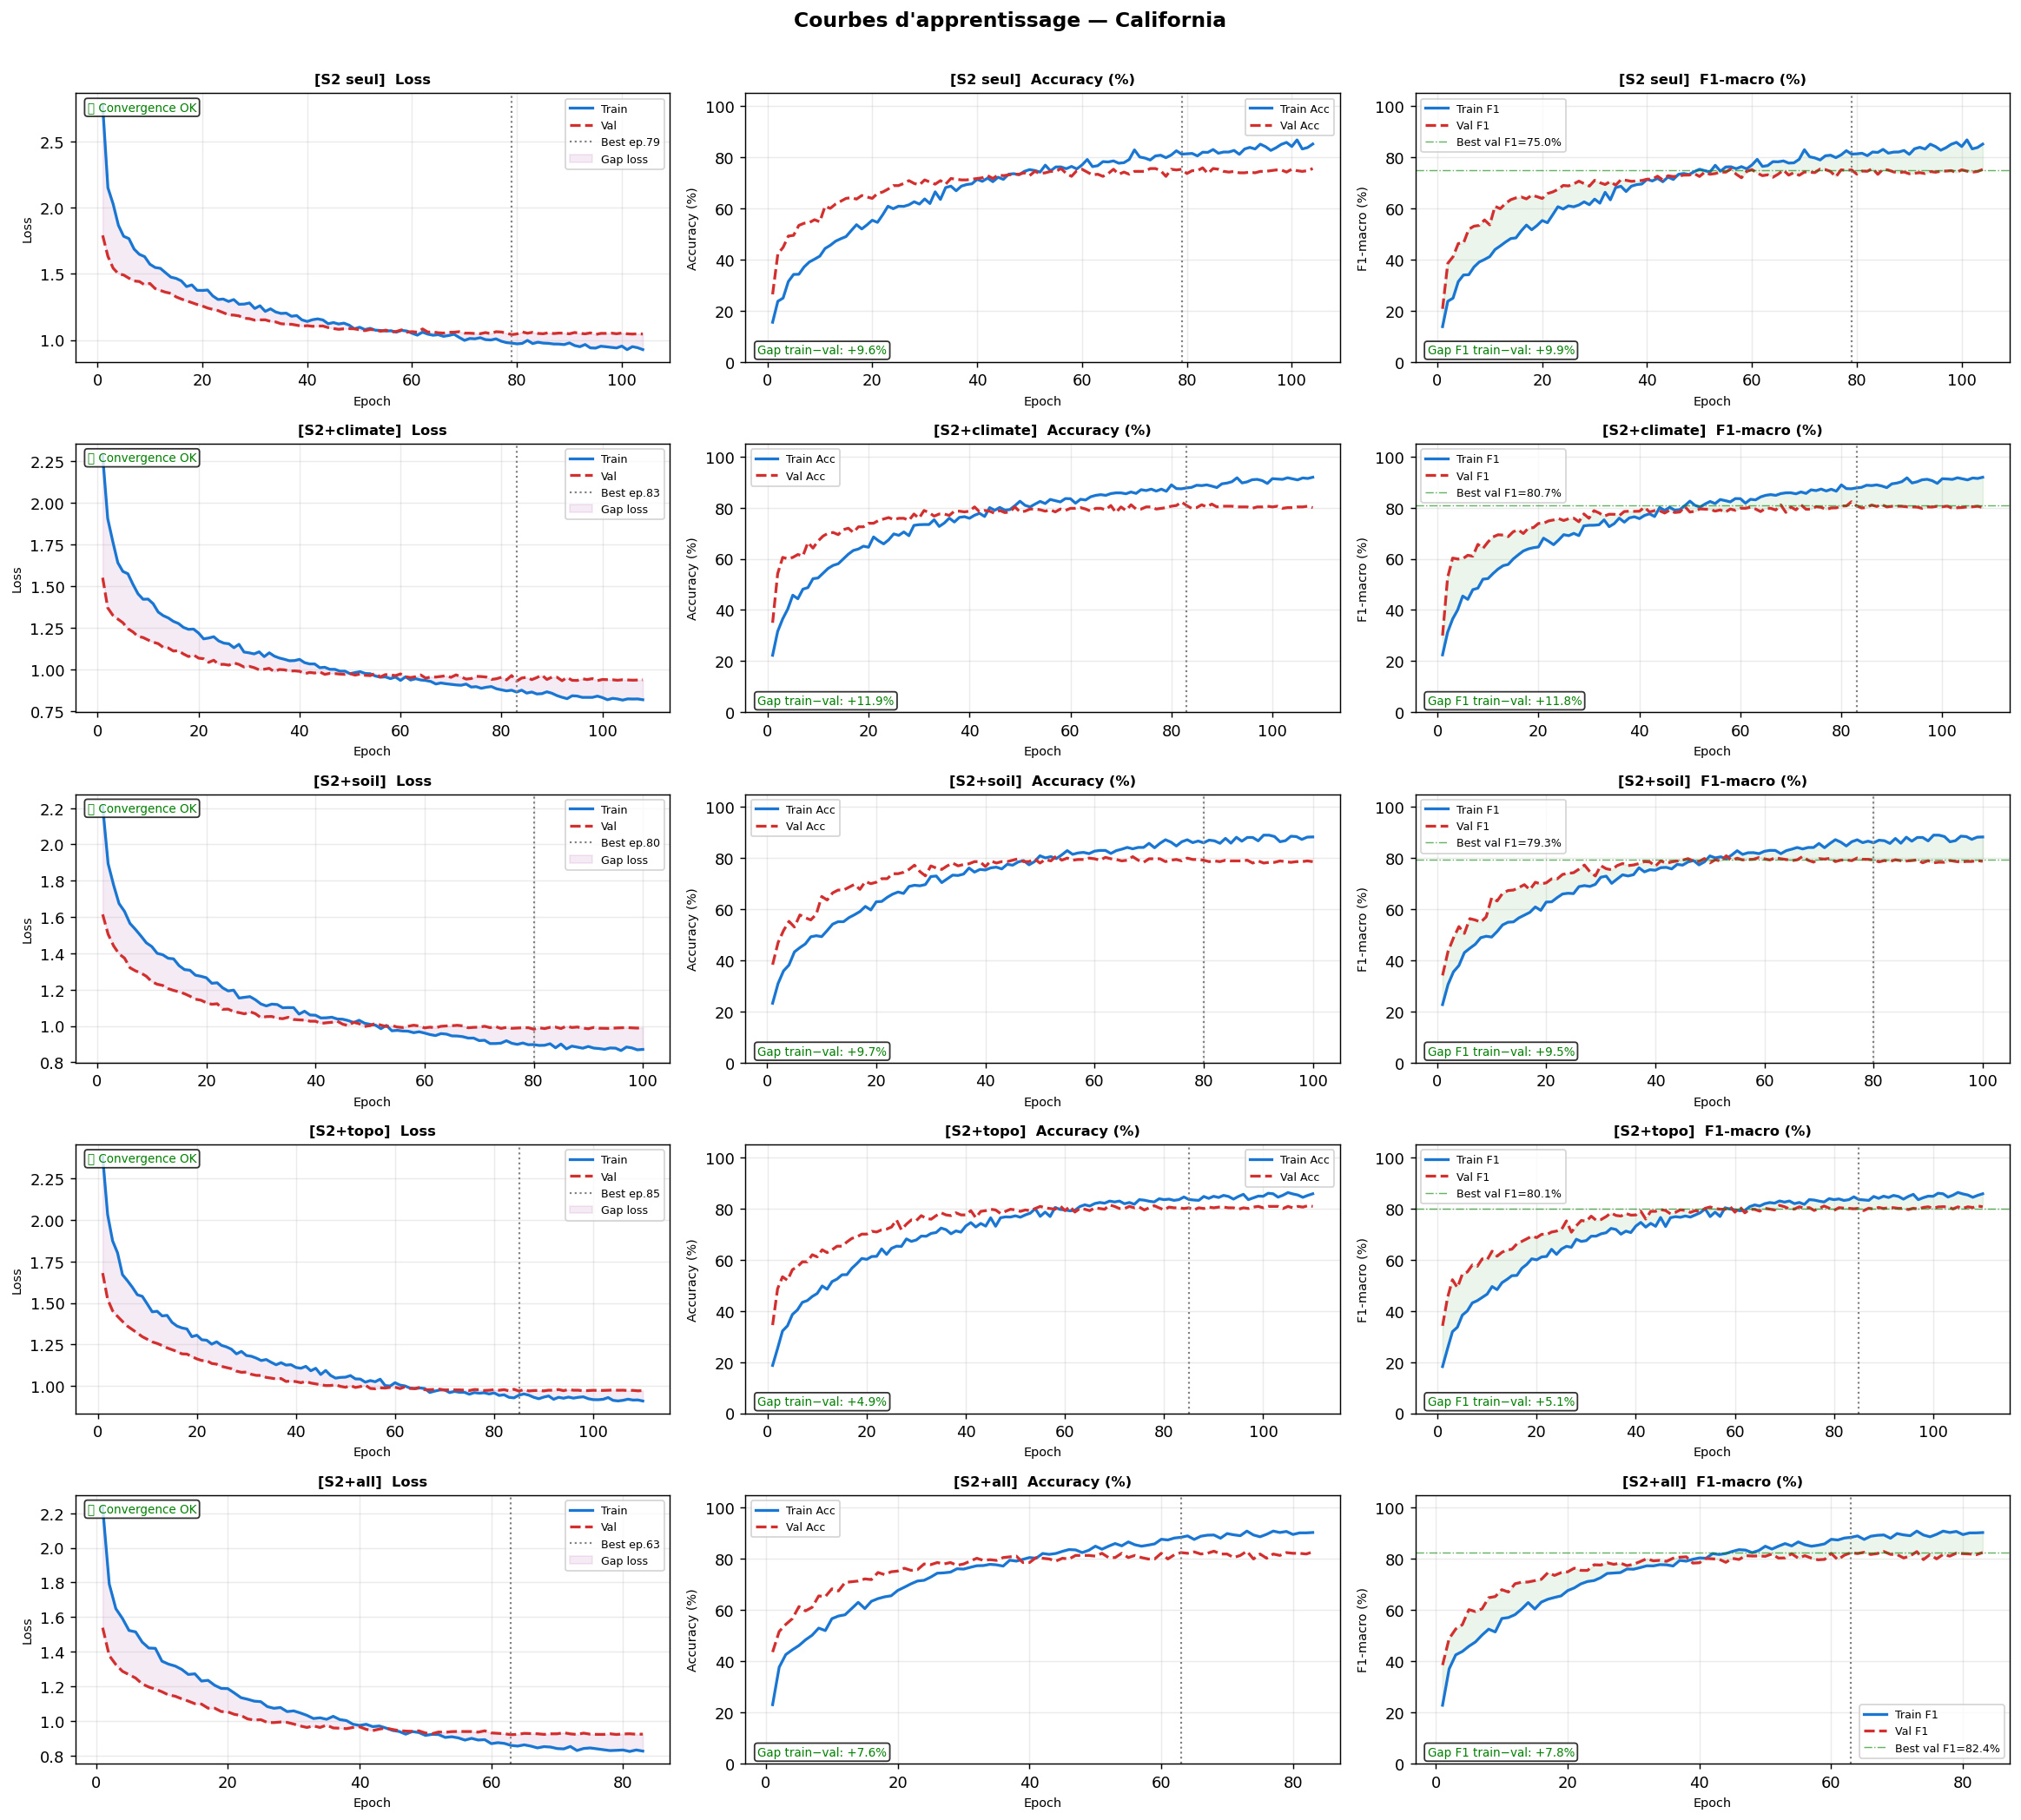


=== Courbes d'apprentissage — ARKANSAS (Loss + Acc + F1) ===
  Sauvegardé : learning_curves_AR.png


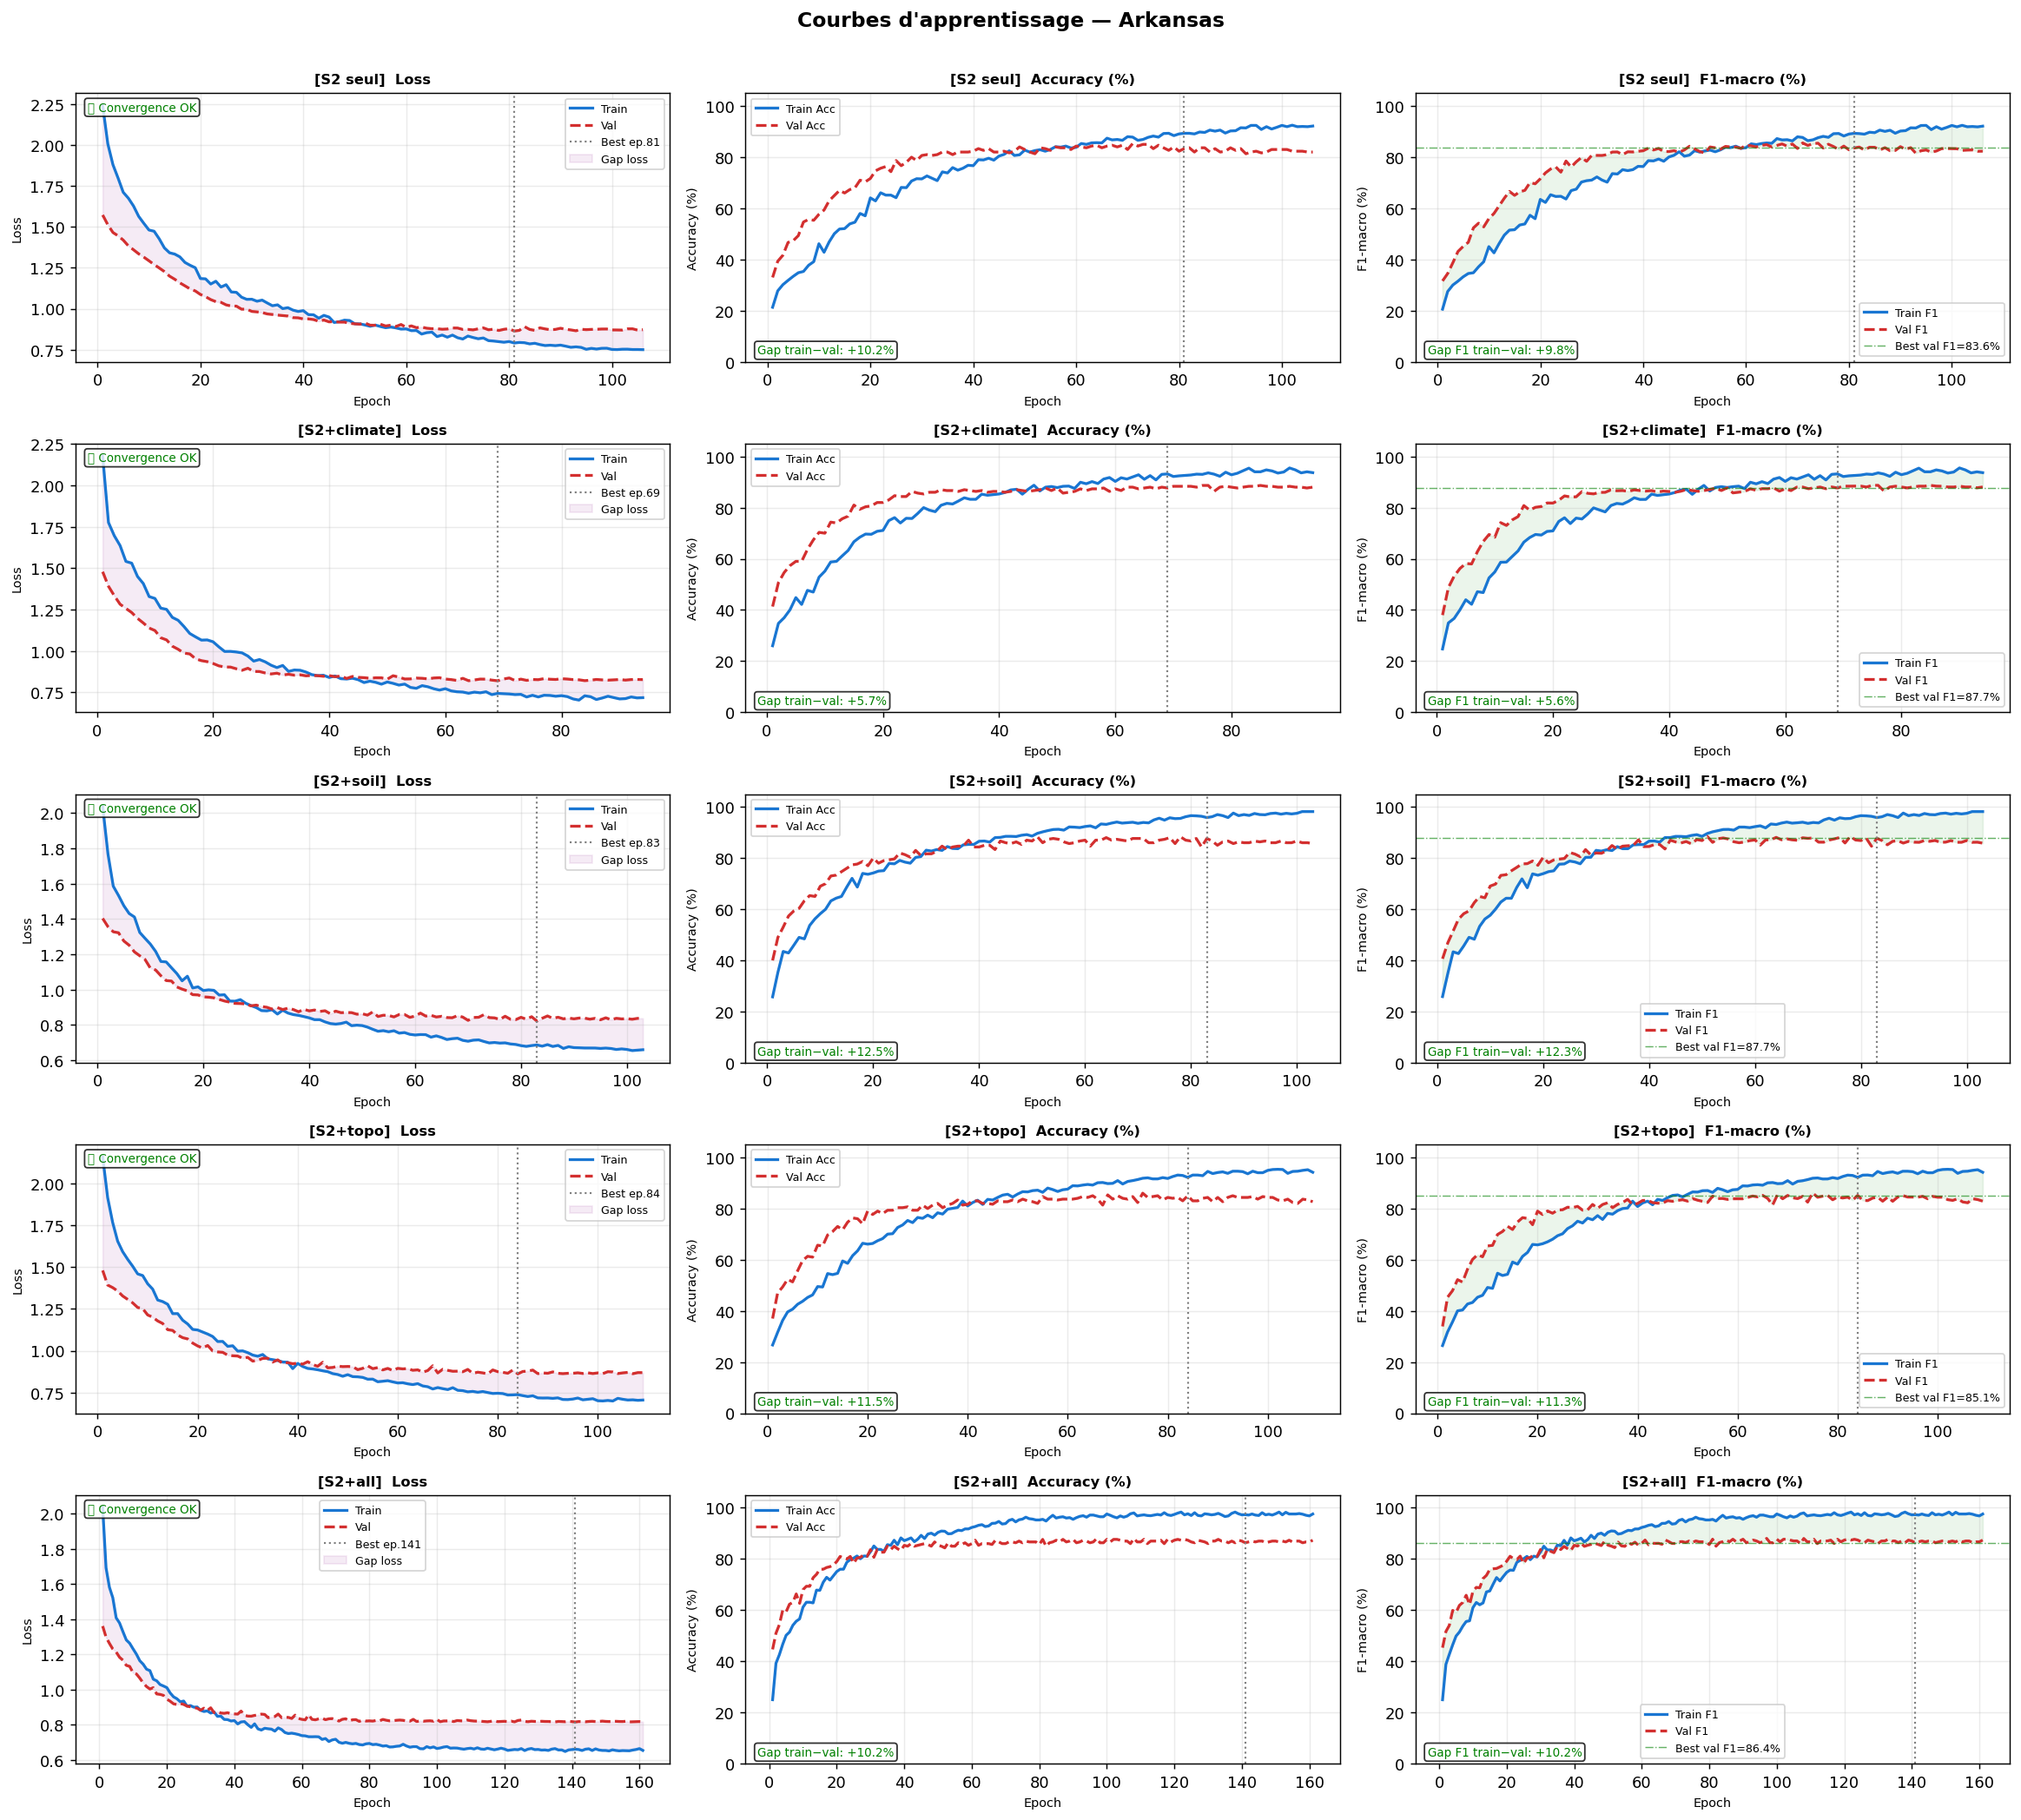


=== Synthèse Overfitting (Acc + F1) ===


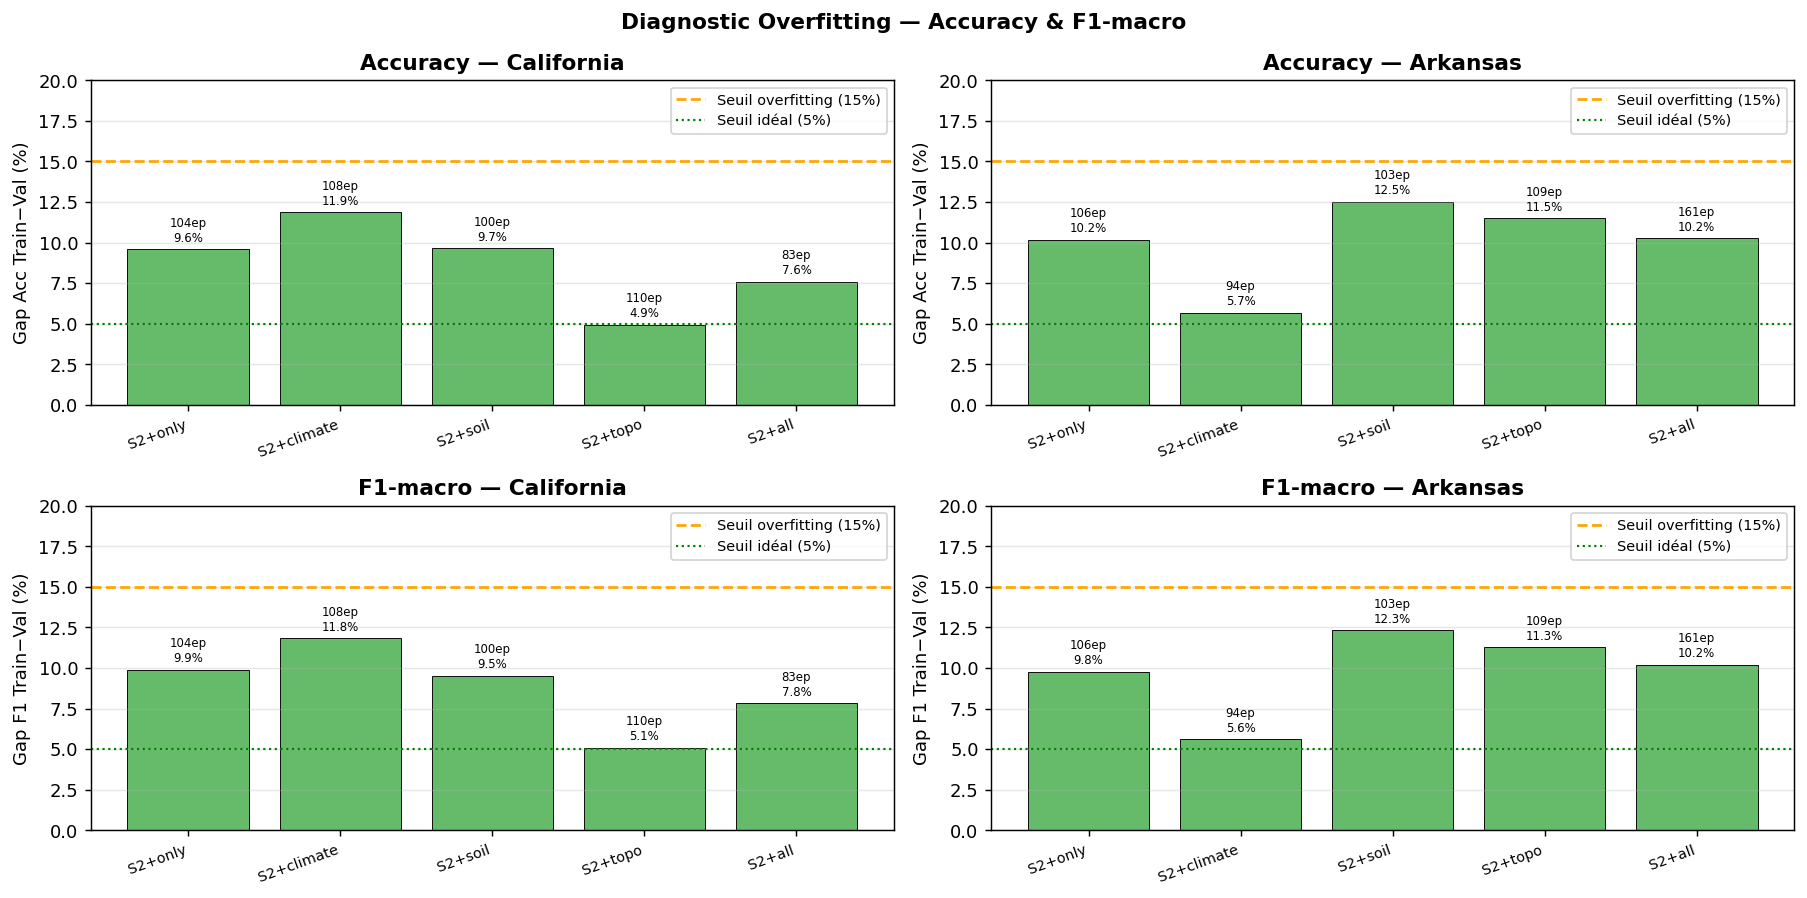

In [9]:
def plot_learning_curves(hists, region_label, configs, save_path=None):
    """
    3 colonnes par configuration :
      - Colonne 1 : Train Loss vs Val Loss
      - Colonne 2 : Train Accuracy vs Val Accuracy
      - Colonne 3 : Train F1-macro vs Val F1-macro  ← nouveau
    Ligne verticale = best epoch (early stop).
    Annotation automatique : overfitting / underfitting / bonne convergence.
    """
    n   = len(configs)
    fig, axes = plt.subplots(n, 3, figsize=(18, 3.2 * n))
    if n == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(f'Courbes d\'apprentissage — {region_label}',
                 fontsize=13, fontweight='bold', y=1.005)

    c_tr = '#1976D2'   # bleu train
    c_va = '#D32F2F'   # rouge val

    for i, cfg in enumerate(configs):
        h       = hists[cfg]
        epochs  = list(range(1, len(h['loss']) + 1))
        best_ep = h.get('best_epoch', len(h['loss']))

        ax_l, ax_a, ax_f = axes[i, 0], axes[i, 1], axes[i, 2]
        cfg_label = cfg.replace('S2_only','S2 seul').replace('S2_','S2+')

        # ── 1. Loss ──────────────────────────────────────────────────────────
        ax_l.plot(epochs, h['loss'],     color=c_tr, lw=1.8, label='Train')
        ax_l.plot(epochs, h['val_loss'], color=c_va, lw=1.8, label='Val',
                  linestyle='--')
        ax_l.axvline(best_ep, color='gray', lw=1.2, linestyle=':',
                     label=f'Best ep.{best_ep}')
        ax_l.fill_between(epochs, h['loss'], h['val_loss'],
                           alpha=0.08, color='purple',
                           label='Gap loss')
        ax_l.set_title(f'[{cfg_label}]  Loss', fontsize=9, fontweight='bold')
        ax_l.set_xlabel('Epoch', fontsize=8)
        ax_l.set_ylabel('Loss', fontsize=8)
        ax_l.legend(fontsize=7); ax_l.grid(True, alpha=0.25)

        gap_loss = h['val_loss'][-1] - h['loss'][-1]
        if gap_loss > 0.3:
            diag, col = '⚠️ Overfitting', 'red'
        elif h['val_loss'][-1] > 1.5:
            diag, col = '⚠️ Underfitting', 'orange'
        else:
            diag, col = '✅ Convergence OK', 'green'
        ax_l.text(0.02, 0.97, diag, transform=ax_l.transAxes,
                  fontsize=7.5, color=col, va='top',
                  bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.8))

        # ── 2. Accuracy ───────────────────────────────────────────────────────
        ax_a.plot(epochs, h['acc'],     color=c_tr, lw=1.8, label='Train Acc')
        ax_a.plot(epochs, h['val_acc'], color=c_va, lw=1.8, label='Val Acc',
                  linestyle='--')
        ax_a.axvline(best_ep, color='gray', lw=1.2, linestyle=':')
        ax_a.set_title(f'[{cfg_label}]  Accuracy (%)', fontsize=9, fontweight='bold')
        ax_a.set_xlabel('Epoch', fontsize=8)
        ax_a.set_ylabel('Accuracy (%)', fontsize=8)
        ax_a.set_ylim(0, 105)
        ax_a.legend(fontsize=7); ax_a.grid(True, alpha=0.25)

        gap_acc = h['acc'][-1] - h['val_acc'][-1]
        ax_a.text(0.02, 0.03,
                  f'Gap train−val: {gap_acc:+.1f}%',
                  transform=ax_a.transAxes, fontsize=7.5,
                  color='red' if gap_acc > 15 else 'green',
                  bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.8))

        # ── 3. F1-macro ───────────────────────────────────────────────────────
        if 'train_f1' in h and 'val_f1' in h:
            ax_f.plot(epochs, [v*100 for v in h['train_f1']],
                      color=c_tr, lw=1.8, label='Train F1')
            ax_f.plot(epochs, [v*100 for v in h['val_f1']],
                      color=c_va, lw=1.8, label='Val F1', linestyle='--')
            ax_f.axvline(best_ep, color='gray', lw=1.2, linestyle=':')
            ax_f.fill_between(
                epochs,
                [v*100 for v in h['train_f1']],
                [v*100 for v in h['val_f1']],
                alpha=0.08, color='green'
            )
            best_vf1 = h['val_f1'][best_ep - 1] * 100
            ax_f.axhline(best_vf1, color='green', lw=0.8, linestyle='-.',
                         alpha=0.6, label=f'Best val F1={best_vf1:.1f}%')
            ax_f.set_title(f'[{cfg_label}]  F1-macro (%)', fontsize=9,
                           fontweight='bold')
            ax_f.set_xlabel('Epoch', fontsize=8)
            ax_f.set_ylabel('F1-macro (%)', fontsize=8)
            ax_f.set_ylim(0, 105)
            ax_f.legend(fontsize=7); ax_f.grid(True, alpha=0.25)

            gap_f1 = (h['train_f1'][-1] - h['val_f1'][-1]) * 100
            ax_f.text(0.02, 0.03,
                      f'Gap F1 train−val: {gap_f1:+.1f}%',
                      transform=ax_f.transAxes, fontsize=7.5,
                      color='red' if gap_f1 > 15 else 'green',
                      bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.8))
        else:
            ax_f.text(0.5, 0.5, 'F1 non disponible\n(ancienne version)',
                      ha='center', va='center', transform=ax_f.transAxes)
            ax_f.set_title(f'[{cfg_label}]  F1-macro', fontsize=9)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  Sauvegardé : {save_path.name}')
    plt.show()


def plot_overfitting_summary(hists_CA, hists_AR, configs):
    """
    Synthèse : gap train−val pour Accuracy ET F1-macro par config/région.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    x      = np.arange(len(configs))
    labels = [c.replace('S2_','S2+').replace('_only',' seul') for c in configs]

    metrics = [
        ('acc',      'val_acc',   'Accuracy',  'Gap Acc Train−Val (%)'),
        ('train_f1', 'val_f1',    'F1-macro',  'Gap F1 Train−Val (%)'),
    ]

    for row, (tr_key, va_key, mname, ylabel) in enumerate(metrics):
        for col, (hists, region) in enumerate(
            [(hists_CA, 'California'), (hists_AR, 'Arkansas')]
        ):
            ax   = axes[row, col]
            gaps = []
            for c in configs:
                h  = hists[c]
                tr = h[tr_key][-1] * (100 if 'f1' in tr_key else 1)
                va = h[va_key][-1] * (100 if 'f1' in va_key else 1)
                gaps.append(tr - va)
            n_ep = [len(hists[c]['loss']) for c in configs]

            bars = ax.bar(x, gaps,
                          color=['#EF5350' if g > 15 else '#66BB6A' for g in gaps],
                          edgecolor='black', linewidth=0.5)
            ax.axhline(15, color='orange', linestyle='--', lw=1.5,
                       label='Seuil overfitting (15%)')
            ax.axhline(5,  color='green',  linestyle=':',  lw=1.2,
                       label='Seuil idéal (5%)')
            ax.set_xticks(x)
            ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
            ax.set_ylabel(ylabel)
            ax.set_title(f'{mname} — {region}', fontweight='bold')
            ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')
            ax.set_ylim(0, max(max(gaps) * 1.35, 20))

            for bar, ep, g in zip(bars, n_ep, gaps):
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.3,
                        f'{ep}ep\n{g:.1f}%',
                        ha='center', va='bottom', fontsize=6.5)

    plt.suptitle('Diagnostic Overfitting — Accuracy & F1-macro',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROCESSED_DIR / 'overfitting_summary.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Tracé ────────────────────────────────────────────────────────────────────
print('=== Courbes d\'apprentissage — CALIFORNIA (Loss + Acc + F1) ===')
plot_learning_curves(hists_CA, 'California', CONFIGS,
                     save_path=PROCESSED_DIR / 'learning_curves_CA.png')

print('\n=== Courbes d\'apprentissage — ARKANSAS (Loss + Acc + F1) ===')
plot_learning_curves(hists_AR, 'Arkansas', CONFIGS,
                     save_path=PROCESSED_DIR / 'learning_curves_AR.png')

print('\n=== Synthèse Overfitting (Acc + F1) ===')
plot_overfitting_summary(hists_CA, hists_AR, CONFIGS)


## 📊 ÉTAPE 6 — Tableau comparatif (Ablation Study)


=== Ablation Study — Résultats ===
Configuration CA — OA (%) CA — Kappa CA — F1 AR — OA (%) AR — Kappa AR — F1
      S2 only       79.78      0.735   0.717       77.32      0.676   0.713
   S2 climate       81.49      0.757   0.741       80.75      0.724   0.748
      S2 soil       81.62      0.758   0.739       79.68      0.710   0.738
      S2 topo       80.27      0.742   0.733       81.39      0.729   0.761
       S2 all       82.95      0.776   0.753       80.61      0.720   0.762


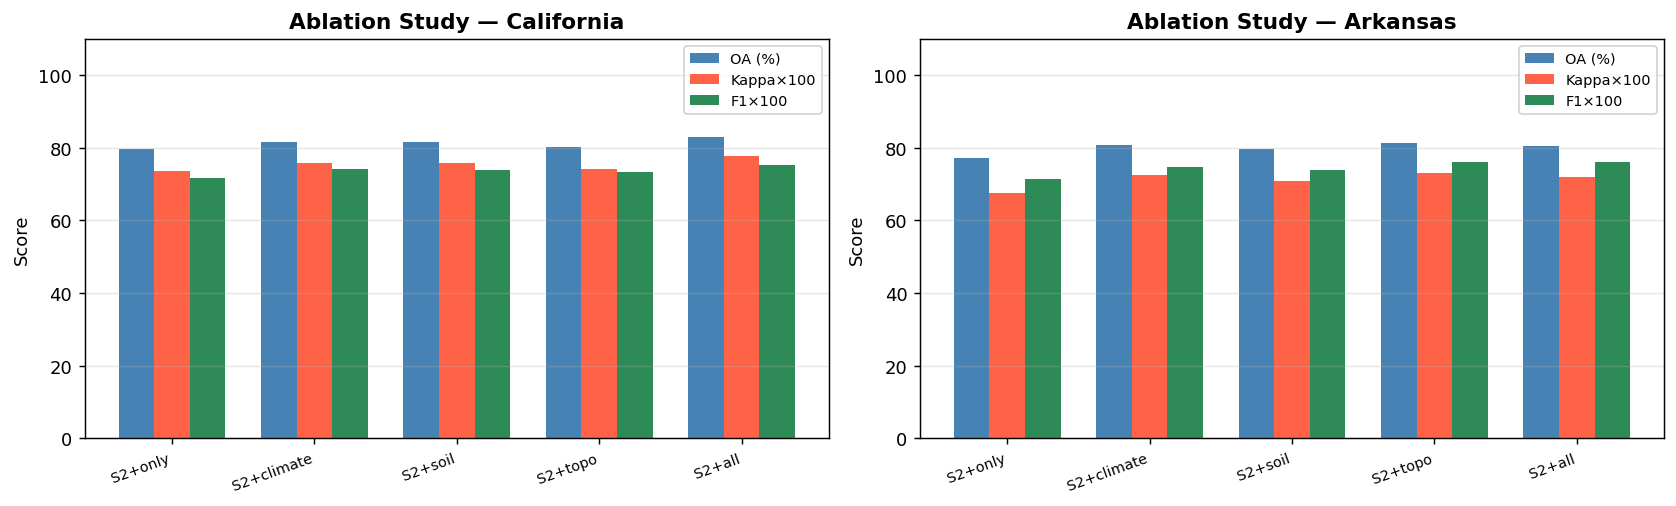

In [10]:
def plot_ablation_table(results_CA, results_AR, configs):
    rows = []
    for cfg in configs:
        ca = results_CA[cfg]
        ar = results_AR[cfg]
        rows.append({
            'Configuration': cfg.replace('_', ' '),
            'CA — OA (%)' : f"{ca['OA']:.2f}",
            'CA — Kappa'  : f"{ca['Kappa']:.3f}",
            'CA — F1'     : f"{ca['F1']:.3f}",
            'AR — OA (%)' : f"{ar['OA']:.2f}",
            'AR — Kappa'  : f"{ar['Kappa']:.3f}",
            'AR — F1'     : f"{ar['F1']:.3f}",
        })
    df = pd.DataFrame(rows)
    print('\n=== Ablation Study — Résultats ===')
    print(df.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    x      = np.arange(len(configs))
    labels = [c.replace('S2_', 'S2+').replace('_only', ' seul') for c in configs]
    w      = 0.25

    for ax, res, region in zip(axes, [results_CA, results_AR], ['California', 'Arkansas']):
        oa    = [res[c]['OA']       for c in configs]
        kappa = [res[c]['Kappa']*100 for c in configs]
        f1    = [res[c]['F1']*100    for c in configs]
        ax.bar(x - w, oa,    w, label='OA (%)',    color='steelblue')
        ax.bar(x,     kappa, w, label='Kappa×100', color='tomato')
        ax.bar(x + w, f1,    w, label='F1×100',    color='seagreen')
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
        ax.set_ylabel('Score')
        ax.set_title(f'Ablation Study — {region}', fontweight='bold')
        ax.legend(fontsize=8)
        ax.set_ylim(0, 110)
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(PROCESSED_DIR / 'ablation_study.png', dpi=150, bbox_inches='tight')
    plt.show()
    return df


df_ablation = plot_ablation_table(results_CA, results_AR, CONFIGS)

## 📊 ÉTAPE 7 — Matrices de confusion (baseline vs meilleure config)

Meilleure config CA : S2_all  (Kappa=0.776)
Meilleure config AR : S2_topo  (Kappa=0.729)


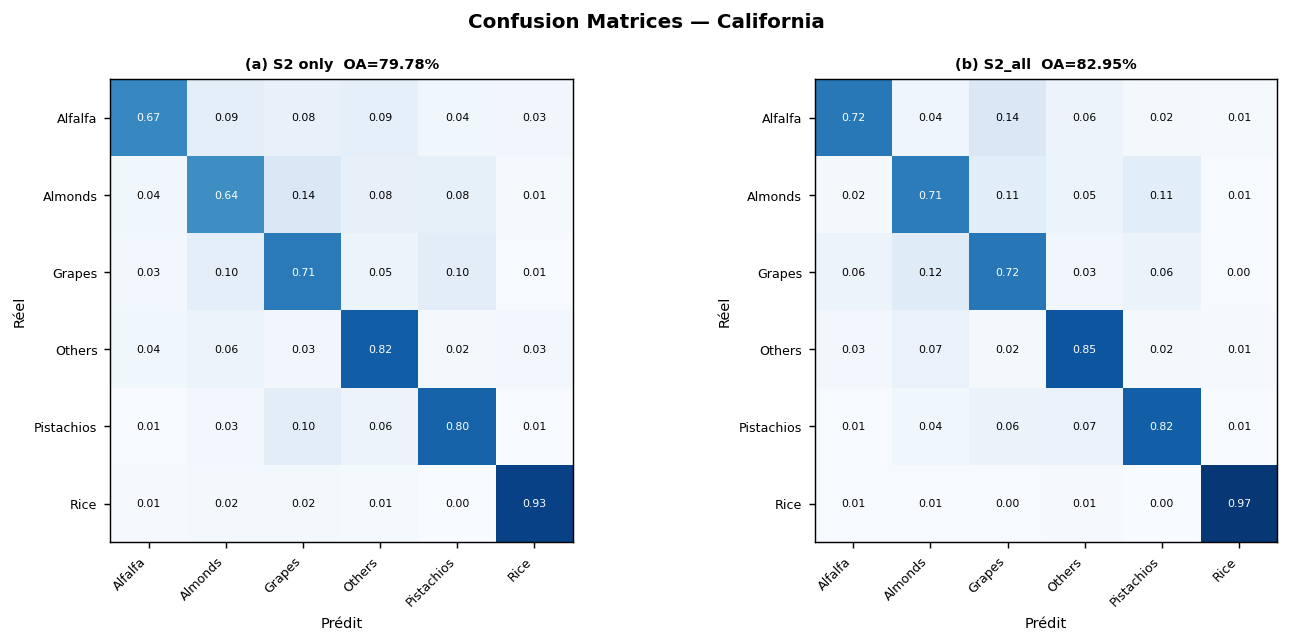

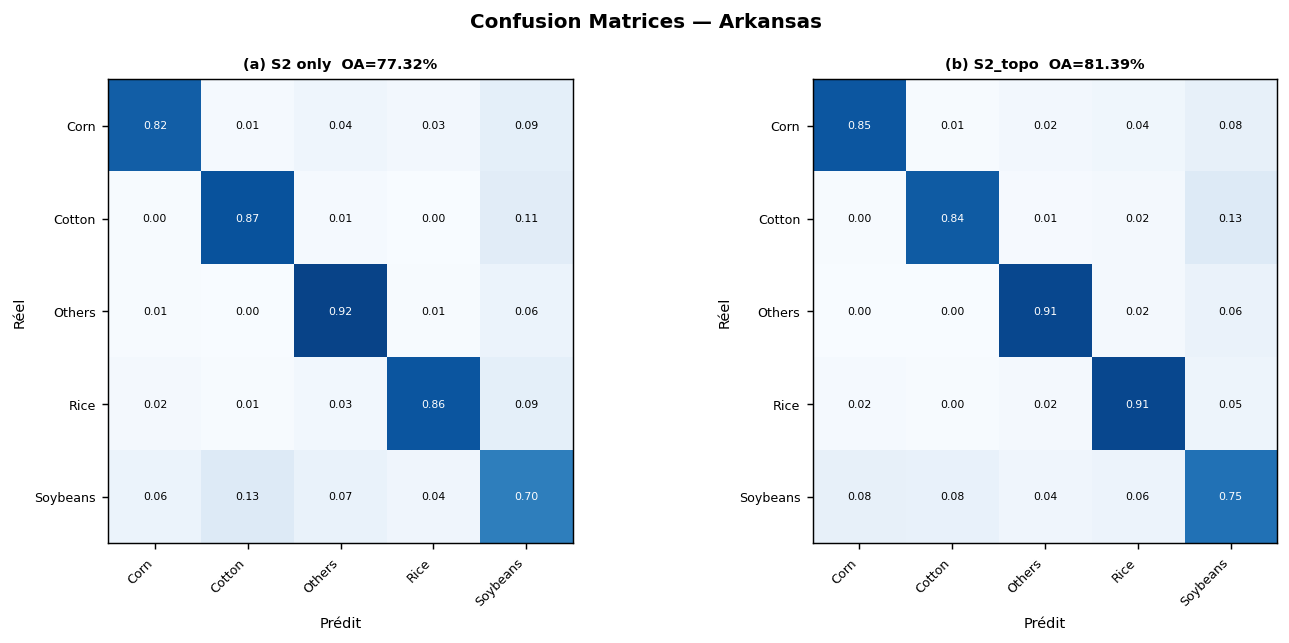

In [11]:
def plot_confusion_matrix(y_true, y_pred, classes, title='', ax=None):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    n  = len(classes)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4.5))
    ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_xticklabels(classes, fontsize=7, rotation=45, ha='right')
    ax.set_yticks(range(n)); ax.set_yticklabels(classes, fontsize=7)
    ax.set_xlabel('Prédit', fontsize=8); ax.set_ylabel('Réel', fontsize=8)
    ax.set_title(title, fontsize=8, fontweight='bold')
    for i in range(n):
        for j in range(n):
            c = 'white' if cm[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center', fontsize=6, color=c)


best_ca = max(CONFIGS, key=lambda c: results_CA[c]['Kappa'])
best_ar = max(CONFIGS, key=lambda c: results_AR[c]['Kappa'])
print(f'Meilleure config CA : {best_ca}  (Kappa={results_CA[best_ca]["Kappa"]:.3f})')
print(f'Meilleure config AR : {best_ar}  (Kappa={results_AR[best_ar]["Kappa"]:.3f})')

# California
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_confusion_matrix(
    results_CA['S2_only']['y_true'], results_CA['S2_only']['pred'],
    le_CA.classes_,
    title=f'(a) S2 only  OA={results_CA["S2_only"]["OA"]:.2f}%', ax=axes[0])
plot_confusion_matrix(
    results_CA[best_ca]['y_true'], results_CA[best_ca]['pred'],
    le_CA.classes_,
    title=f'(b) {best_ca}  OA={results_CA[best_ca]["OA"]:.2f}%', ax=axes[1])
plt.suptitle('Confusion Matrices — California', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'confusion_ca_part2.png', dpi=150, bbox_inches='tight')
plt.show()

# Arkansas
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_confusion_matrix(
    results_AR['S2_only']['y_true'], results_AR['S2_only']['pred'],
    le_AR.classes_,
    title=f'(a) S2 only  OA={results_AR["S2_only"]["OA"]:.2f}%', ax=axes[0])
plot_confusion_matrix(
    results_AR[best_ar]['y_true'], results_AR[best_ar]['pred'],
    le_AR.classes_,
    title=f'(b) {best_ar}  OA={results_AR[best_ar]["OA"]:.2f}%', ax=axes[1])
plt.suptitle('Confusion Matrices — Arkansas', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'confusion_ar_part2.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔥 ÉTAPE 8 — Grad-CAM : Visualisation des features importantes (Style Paper 1)

**Inspiré de la Figure 9 du Paper 1 (Wang et al., 2021)** : heatmap 2D (bandes spectrales × temps) montrant quelles bandes et quelles dates le modèle regarde le plus pour chaque culture.

- Rouge/chaud = forte attention → features importantes pour la classification
- Bleu/froid = faible attention → features ignorées

Permet d'interpréter le modèle : valide-t-il la phénologie connue des cultures ?

=== Récapitulatif des dimensions par configuration ===
Config          N bandes  N dates N features
---------------------------------------------
S2_only               10       36        360
S2_climate            13       36        468
S2_soil               13       36        468
S2_topo               12       36        432
S2_all                18       36        648

=== Grad-CAM — style Figure 9 (Paper 1) ===
(Train Loss ✅  Val Loss ✅  Train Acc ✅  Val Acc ✅ déjà tracés Étape 5b)

--- California | S2_only (10 bandes × 36 = 360 features) ---
  Sauvegardé : gradcam_CA_S2_only.png


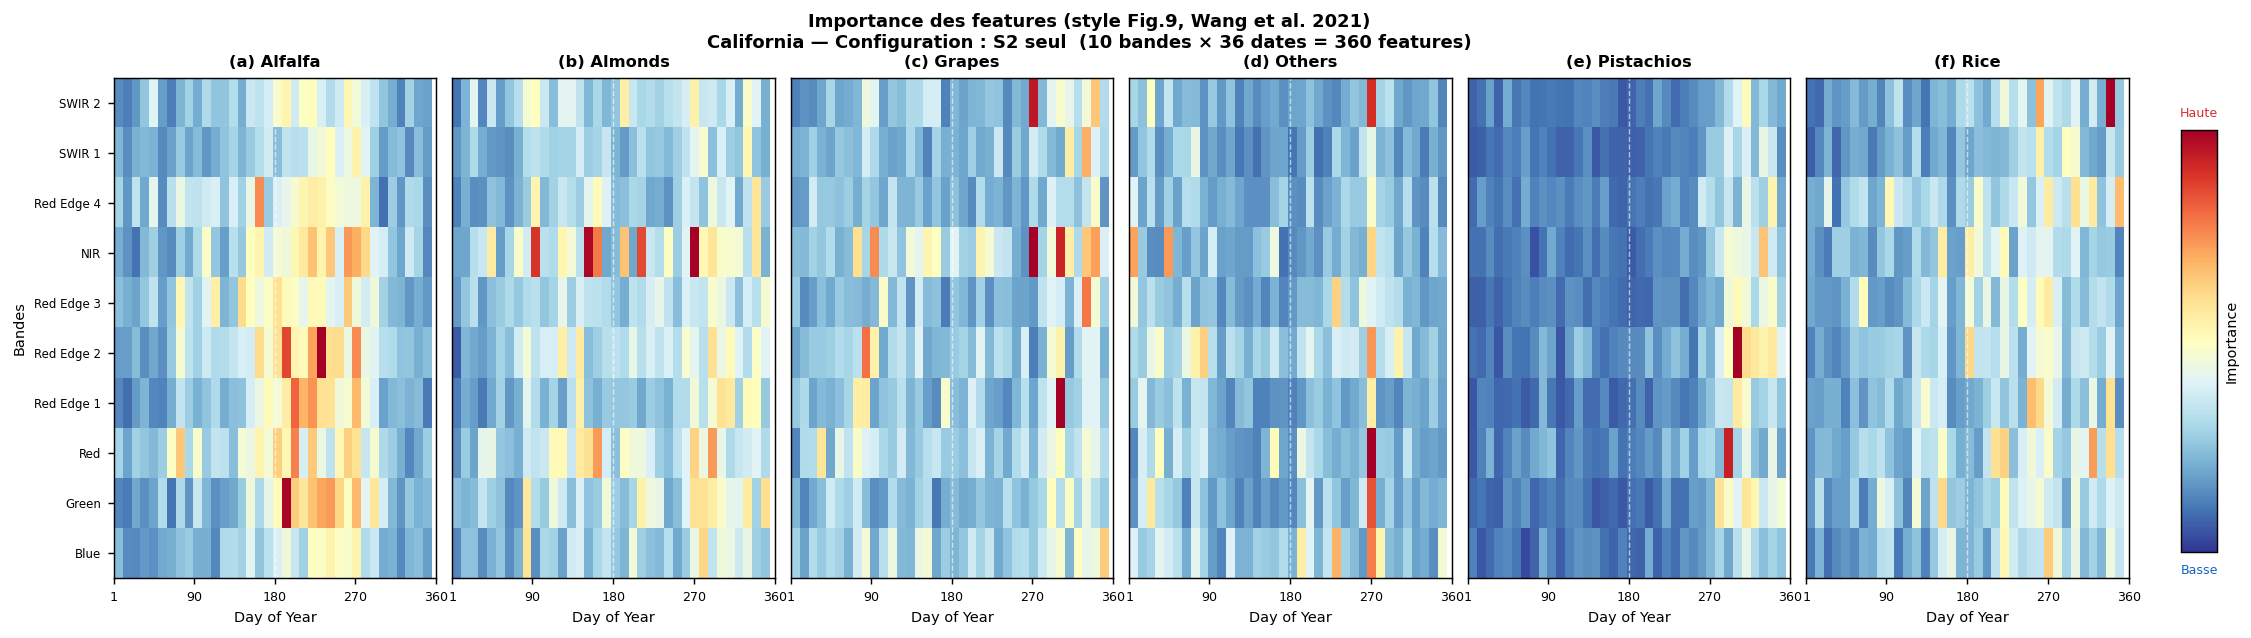

--- Arkansas | S2_only (10 bandes × 36 = 360 features) ---
  Sauvegardé : gradcam_AR_S2_only.png


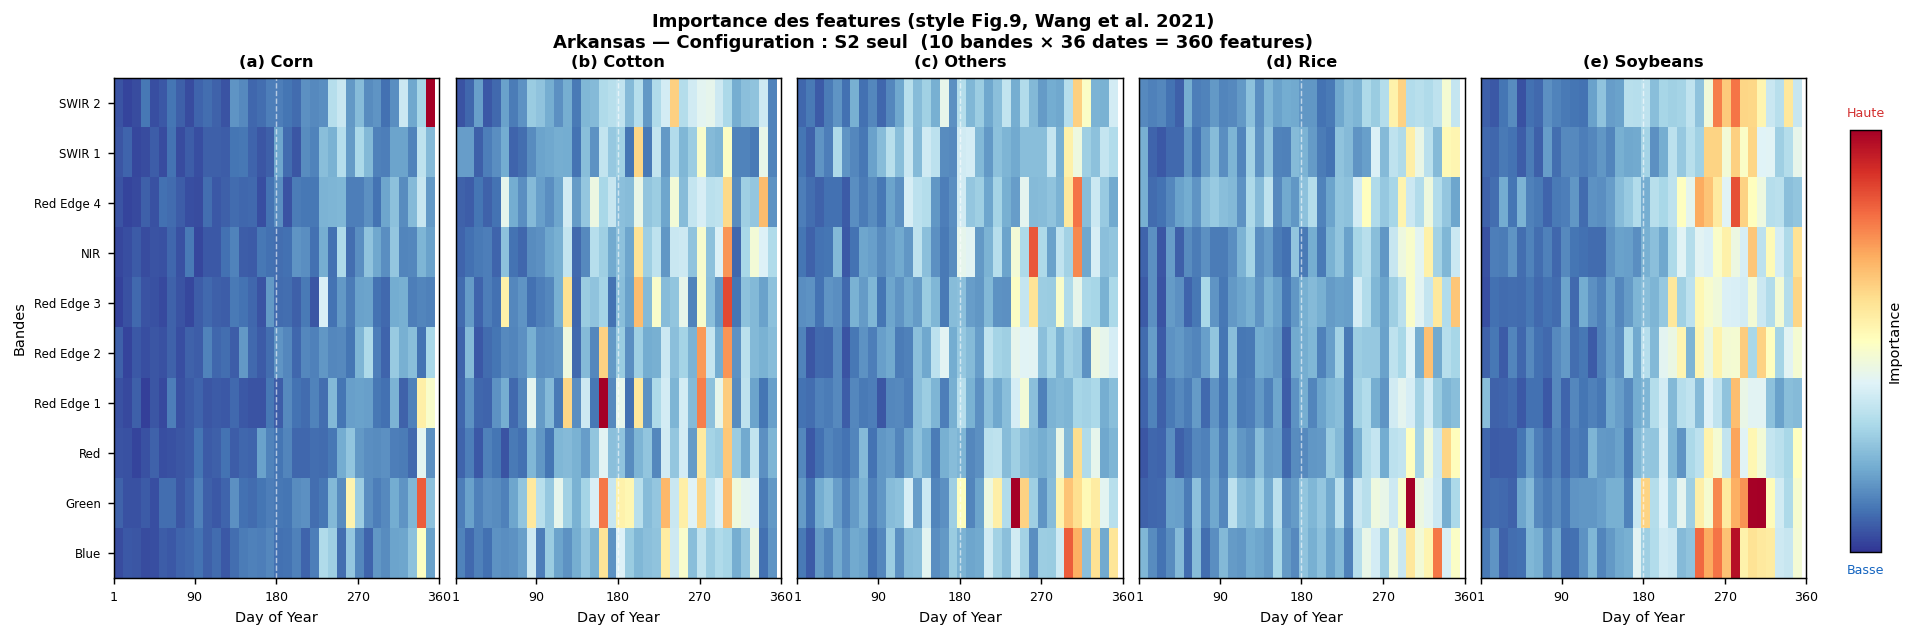

--- California | S2_all (18 bandes × 36 = 648 features) ---
  Sauvegardé : gradcam_CA_S2_all.png


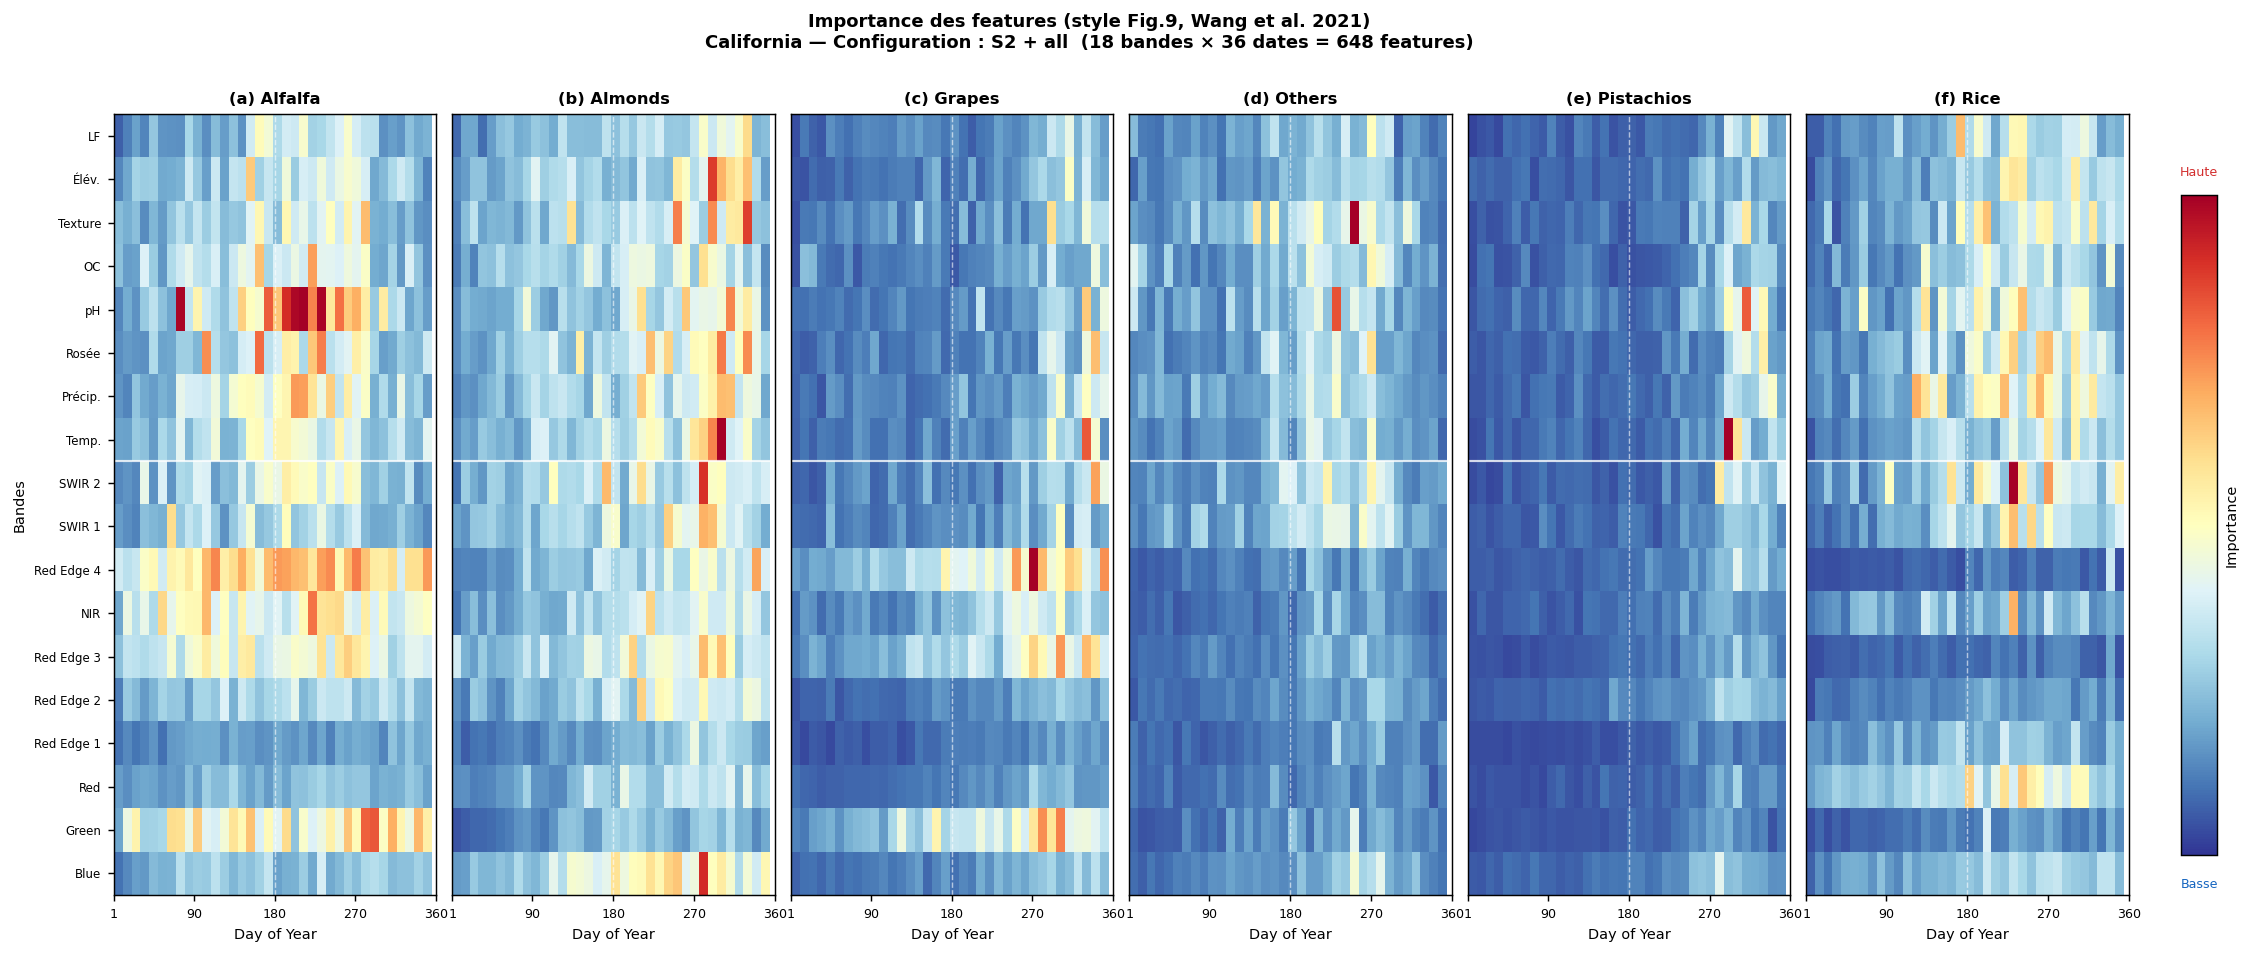

--- Arkansas | S2_all (18 bandes × 36 = 648 features) ---
  Sauvegardé : gradcam_AR_S2_all.png


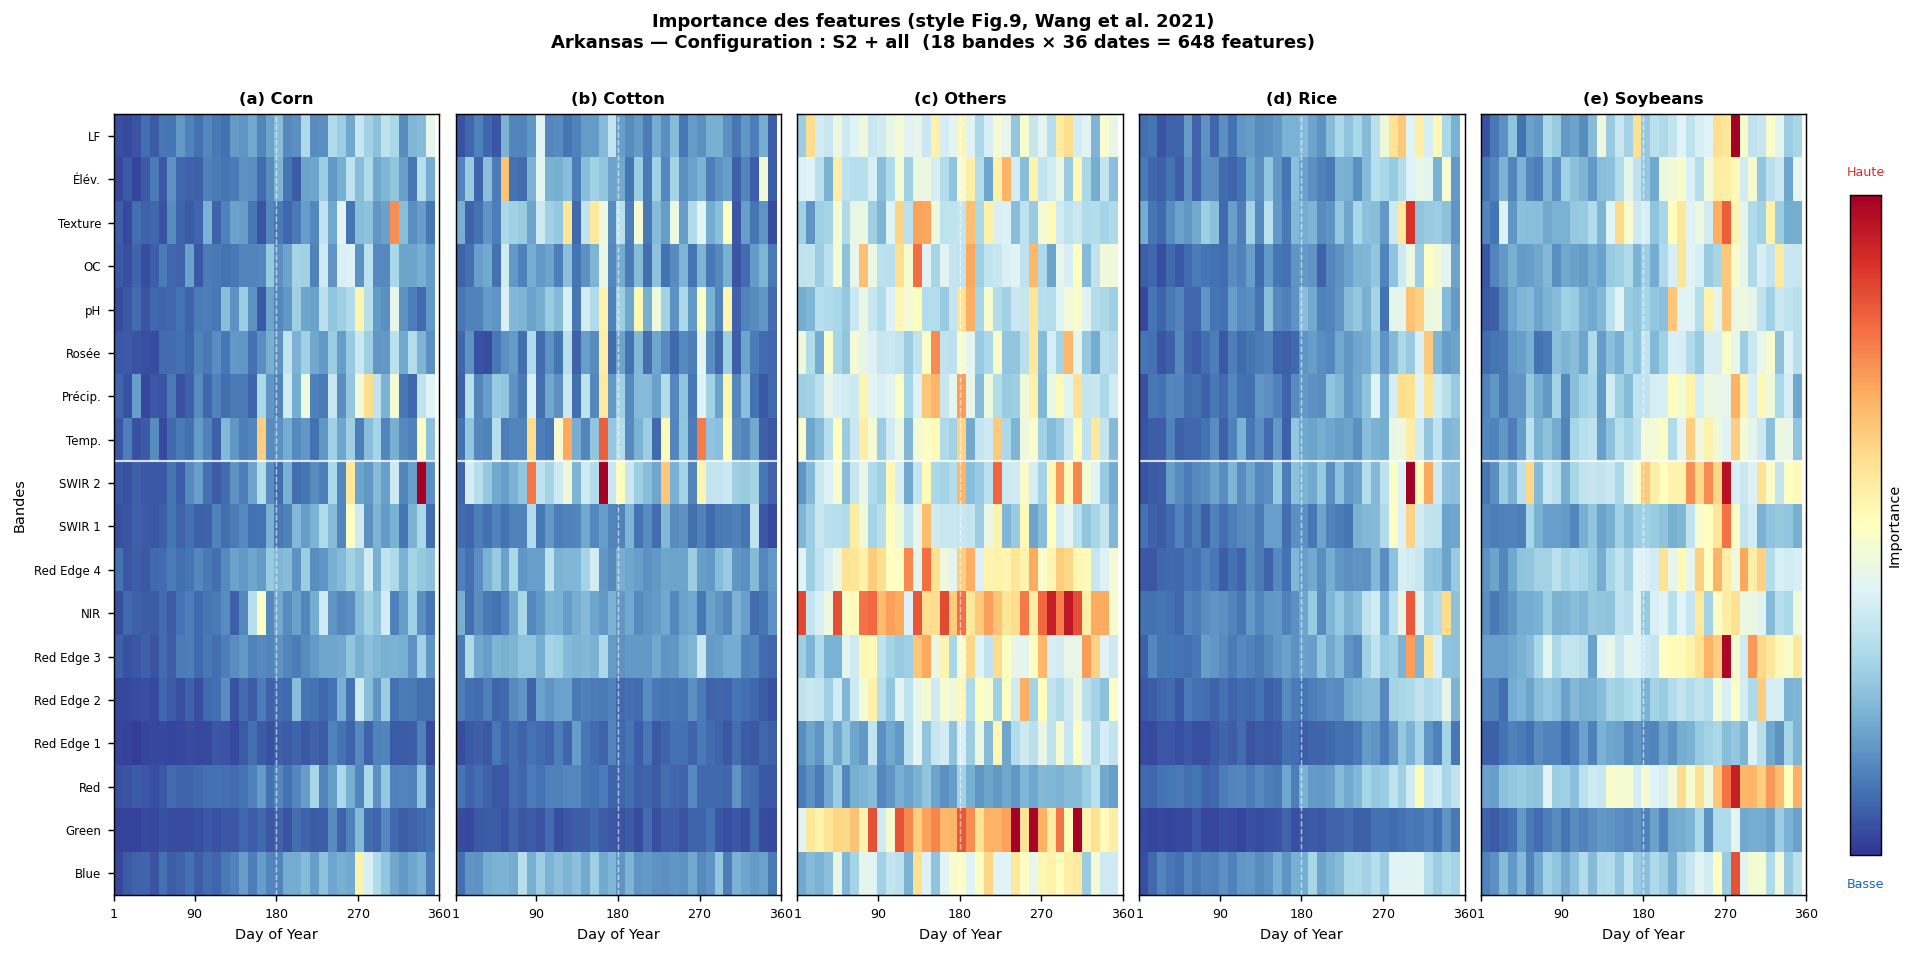


✅ Grad-CAM terminé


In [12]:
import torch.nn.functional as F

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 8 — Grad-CAM style Figure 9 (Wang et al., 2021)
#
# Résumé des dimensions par configuration :
#   S2_only    : 10 bandes × 36 dates = 360  features
#   S2_climate : 13 bandes × 36 dates = 468  features  (+Temp, Precip, Dewpoint)
#   S2_soil    : 13 bandes × 36 dates = 468  features  (+pH, OC, Texture)
#   S2_topo    : 12 bandes × 36 dates = 432  features  (+Elevation, Landforms)
#   S2_all     : 18 bandes × 36 dates = 648  features  (+Temp,Precip,Dew,pH,OC,Tex,Elev,LF)
# ═══════════════════════════════════════════════════════════════════════════

# ── Noms de bandes par configuration ────────────────────────────────────────
S2_BASE_BANDS = ['Blue', 'Green', 'Red',
                  'Red Edge 1', 'Red Edge 2', 'Red Edge 3',
                  'NIR', 'Red Edge 4', 'SWIR 1', 'SWIR 2']

EXTRA_BANDS = {
    'S2_only'   : [],
    'S2_climate': ['Température', 'Précip.', 'Point rosée'],
    'S2_soil'   : ['pH', 'Carb. org.', 'Texture'],
    'S2_topo'   : ['Élévation', 'Landforms'],
    'S2_all'    : ['Temp.', 'Précip.', 'Rosée', 'pH', 'OC', 'Texture', 'Élév.', 'LF'],
}

def get_band_names(config_name):
    return S2_BASE_BANDS + EXTRA_BANDS.get(config_name, [])


def compute_gradcam_per_class(model, datasets, config_name, device,
                               le, n_samples_per_class=50):
    """
    Calcule l'importance des features (Input Gradient × Input) par classe.
    Approche : gradient intégré simplifié (SmoothGrad-like) via gradient de l'entrée.

    Retourne : {class_name : np.array (N_DATES, n_bands_total)}
    """
    d             = datasets[config_name]
    n_bands_total = d['n_bands_total']
    X_test        = d['X_test']
    y_test        = d['y_test']

    grad_cam_dict = {}
    model.eval()

    for cls_idx, cls_name in enumerate(le.classes_):
        mask  = (y_test == cls_idx)
        X_cls = X_test[mask][:n_samples_per_class]
        if len(X_cls) == 0:
            continue

        cam_accum = np.zeros((N_DATES, n_bands_total), dtype=np.float32)

        for i in range(len(X_cls)):
            x = torch.from_numpy(X_cls[i:i+1]).to(device).float()
            x.requires_grad_(True)

            logits = model(x)                          # (1, C)
            score  = logits[0, cls_idx]
            model.zero_grad()
            score.backward()

            # Gradient × Input (Saliency map)
            grad_inp = x.grad.cpu().numpy()[0]         # (N_DATES * n_bands_total,)
            inp_val  = X_cls[i]                        # (N_DATES * n_bands_total,)

            saliency = np.abs(grad_inp * inp_val)      # element-wise
            saliency = saliency.reshape(N_DATES, n_bands_total)
            saliency /= (saliency.max() + 1e-8)        # normalise [0, 1]

            cam_accum += saliency

        grad_cam_dict[cls_name] = cam_accum / max(len(X_cls), 1)

    return grad_cam_dict


def plot_gradcam_figure9(grad_cam_dict, config_name, region_label,
                          n_bands_total, save_path=None):
    """
    Reproduit la Figure 9 du Paper 1 (Wang et al., 2021) :
    Grille de heatmaps 2D par culture :
      - Axe X = Day of Year (36 timesteps)
      - Axe Y = Bandes spectrales + covariables (bas→haut)
      - Couleur chaude (rouge/jaune) = forte importance
      - Couleur froide (bleu) = faible importance
    """
    band_names = get_band_names(config_name)[:n_bands_total]
    classes    = list(grad_cam_dict.keys())
    n_cls      = len(classes)

    # Axe X : Day of Year uniformément réparti sur 365 jours
    doy_axis = [int(i * 365 / N_DATES) + 1 for i in range(N_DATES)]

    # Hauteur figure proportionnelle au nombre de bandes
    fig_h = max(4.0, n_bands_total * 0.35 + 1.5)
    fig, axes = plt.subplots(1, n_cls,
                              figsize=(3.2 * n_cls + 0.8, fig_h),
                              squeeze=False)

    title_cfg = config_name.replace('S2_only', 'S2 seul').replace('S2_', 'S2 + ')
    fig.suptitle(
        f'Importance des features (style Fig.9, Wang et al. 2021)\n'
        f'{region_label} — Configuration : {title_cfg}  '
        f'({n_bands_total} bandes × {N_DATES} dates = {n_bands_total*N_DATES} features)',
        fontsize=10, fontweight='bold'
    )

    im_ref = None
    for j, cls_name in enumerate(classes):
        ax  = axes[0, j]
        cam = grad_cam_dict[cls_name]        # (N_DATES, n_bands_total)

        # Transpose : affiche bandes en Y, dates en X (comme Paper 1)
        cam_T = cam.T                        # (n_bands_total, N_DATES)

        im = ax.imshow(
            cam_T, aspect='auto', cmap='RdYlBu_r',
            vmin=0, vmax=cam_T.max(),
            extent=[doy_axis[0], doy_axis[-1], -0.5, n_bands_total - 0.5]
        )
        im_ref = im

        ax.set_title(f'({chr(97 + j)}) {cls_name}', fontsize=9, fontweight='bold')
        ax.set_xlabel('Day of Year', fontsize=8)

        if j == 0:
            ax.set_ylabel('Bandes', fontsize=8)
            ax.set_yticks(range(n_bands_total))
            ax.set_yticklabels(band_names, fontsize=6.5)
        else:
            ax.set_yticks([])

        ax.set_xticks([1, 90, 180, 270, 360])
        ax.set_xticklabels(['1', '90', '180', '270', '360'], fontsize=7)
        ax.tick_params(axis='x', labelsize=7)

        # Ligne verticale DOY 180 (milieu d'année) — référence phénologique
        ax.axvline(180, color='white', linestyle='--', lw=0.8, alpha=0.6)

        # Séparation visuelle S2 / covariables
        if n_bands_total > 10:
            ax.axhline(9.5, color='white', linestyle='-', lw=1.2, alpha=0.8)
            if j == 0:
                ax.text(-8, 4.5, 'S2', fontsize=6, color='white',
                         rotation=90, va='center', ha='right', fontweight='bold')
                ax.text(-8, 10.5, 'Cov.', fontsize=6, color='white',
                         rotation=90, va='center', ha='right', fontweight='bold')

    # Colorbar commune
    if im_ref is not None:
        cbar_ax = fig.add_axes([0.92, 0.15, 0.014, 0.65])
        cb = fig.colorbar(im_ref, cax=cbar_ax)
        cb.set_label('Importance', fontsize=8)
        cb.ax.yaxis.set_ticks([])
        cb.ax.text(0.5, 1.03, 'Haute', ha='center', fontsize=7,
                   transform=cb.ax.transAxes, color='#D32F2F')
        cb.ax.text(0.5, -0.05, 'Basse', ha='center', fontsize=7,
                   transform=cb.ax.transAxes, color='#1565C0')

    plt.subplots_adjust(right=0.90, wspace=0.05)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  Sauvegardé : {save_path.name}')
    plt.show()


# ── Tableau récap des dimensions ──────────────────────────────────────────────
print('=== Récapitulatif des dimensions par configuration ===')
print(f'{"Config":<15} {"N bandes":>8} {"N dates":>8} {"N features":>10}')
print('-' * 45)
config_bands = {'S2_only': 10, 'S2_climate': 13, 'S2_soil': 13,
                'S2_topo': 12, 'S2_all': 18}
for cfg, nb_ in config_bands.items():
    print(f'{cfg:<15} {nb_:>8} {N_DATES:>8} {nb_*N_DATES:>10}')

# ── Calcul et affichage Grad-CAM ──────────────────────────────────────────────
print('\n=== Grad-CAM — style Figure 9 (Paper 1) ===')
print('(Train Loss ✅  Val Loss ✅  Train Acc ✅  Val Acc ✅ déjà tracés Étape 5b)')
print()

for cfg in ['S2_only', 'S2_all']:
    n_bands_CA = datasets_CA[cfg]['n_bands_total']
    n_bands_AR = datasets_AR[cfg]['n_bands_total']

    print(f'--- California | {cfg} ({n_bands_CA} bandes × {N_DATES} = {n_bands_CA*N_DATES} features) ---')
    gc_CA = compute_gradcam_per_class(models_CA[cfg], datasets_CA, cfg,
                                       DEVICE, le_CA, n_samples_per_class=40)
    plot_gradcam_figure9(gc_CA, cfg, 'California', n_bands_CA,
                          save_path=PROCESSED_DIR / f'gradcam_CA_{cfg}.png')

    print(f'--- Arkansas | {cfg} ({n_bands_AR} bandes × {N_DATES} = {n_bands_AR*N_DATES} features) ---')
    gc_AR = compute_gradcam_per_class(models_AR[cfg], datasets_AR, cfg,
                                       DEVICE, le_AR, n_samples_per_class=40)
    plot_gradcam_figure9(gc_AR, cfg, 'Arkansas', n_bands_AR,
                          save_path=PROCESSED_DIR / f'gradcam_AR_{cfg}.png')

print('\n✅ Grad-CAM terminé')

# ── Décommenter pour toutes les configs ──────────────────────────────────────
# for cfg in CONFIGS:
#     for datasets, models, le, region, tag in [
#         (datasets_CA, models_CA, le_CA, 'California', 'CA'),
#         (datasets_AR, models_AR, le_AR, 'Arkansas',   'AR'),
#     ]:
#         nb_  = datasets[cfg]['n_bands_total']
#         gc   = compute_gradcam_per_class(models[cfg], datasets, cfg, DEVICE, le)
#         plot_gradcam_figure9(gc, cfg, region, nb_,
#                              save_path=PROCESSED_DIR / f'gradcam_{tag}_{cfg}.png')


## 💾 Sauvegarde des résultats

In [13]:
# ── 1. Tableau ablation ───────────────────────────────────────────────────────
df_ablation.to_csv(PROCESSED_DIR / 'ablation_results.csv', index=False)
print(f'✅ Tableau ablation : {PROCESSED_DIR}/ablation_results.csv')

# ── 2. Modèles .pth ───────────────────────────────────────────────────────────
for cfg in CONFIGS:
    torch.save(models_CA[cfg].state_dict(), MODEL_DIR / f'part2_CA_{cfg}.pth')
    torch.save(models_AR[cfg].state_dict(), MODEL_DIR / f'part2_AR_{cfg}.pth')
print(f'✅ Modèles         : {MODEL_DIR}/part2_*.pth')

# ── 3. CSV enrichis — un fichier par config × région ─────────────────────────
# Chaque CSV contient :
#   - toutes les features enrichies (flatten : n_bandes_total × 36 colonnes)
#   - la colonne 'crop_label' (nom de la classe)
#   - la colonne 'split'  (train / val / test)
#   - la colonne 'y'      (label encodé)
#   - la colonne 'pred'   (prédiction du modèle sur TOUT le dataset)

def save_enriched_csv(csv_path, datasets, models, le, results, label_map,
                       region_tag, configs, processed_dir, device):
    """
    Pour chaque config :
      1. Recharge le CSV source pour récupérer crop_label & split
      2. Concatène train+val+test dans le bon ordre
      3. Ajoute les features enrichies + prédictions
      4. Sauvegarde dans processed_dir/enriched_{region_tag}_{config}.csv
    """
    # Recharge le CSV source pour avoir crop_label et split
    df_src = pd.read_csv(csv_path)
    if 'label' in df_src.columns and 'crop_label' not in df_src.columns:
        df_src = df_src.rename(columns={'label': 'crop_label'})
    if label_map is not None:
        df_src['crop_label'] = df_src['crop_label'].map(label_map).fillna('Others')

    # Recrée le split si absent (même seed → même résultat)
    le_tmp = LabelEncoder()
    df_src['y'] = le_tmp.fit_transform(df_src['crop_label'])
    if 'split' not in df_src.columns:
        idx   = df_src.index.values
        y_all = df_src['y'].values
        idx_tr, idx_tmp2, _, y_tmp2 = train_test_split(
            idx, y_all, test_size=0.30, random_state=RANDOM_STATE, stratify=y_all)
        idx_va, idx_te = train_test_split(
            idx_tmp2, test_size=0.50, random_state=RANDOM_STATE, stratify=y_tmp2)
        df_src['split'] = 'train'
        df_src.loc[idx_va, 'split'] = 'val'
        df_src.loc[idx_te, 'split'] = 'test'

    for cfg in configs:
        d     = datasets[cfg]
        model = models[cfg]
        n_b   = d['n_bands_total']

        # Concatène train + val + test dans l'ordre original
        X_all = np.concatenate([d['X_train'], d['X_val'], d['X_test']], axis=0)
        y_all = np.concatenate([d['y_train'], d['y_val'], d['y_test']], axis=0)

        # Prédictions sur tout le dataset
        model.eval()
        with torch.no_grad():
            pred_all = model(
                torch.from_numpy(X_all).to(device)
            ).argmax(1).cpu().numpy()

        # Noms de colonnes : B1_t0 … Bk_tN + covariables
        n_features = X_all.shape[1]
        feat_names = [f'feat_{i}' for i in range(n_features)]

        df_out = pd.DataFrame(X_all, columns=feat_names)

        # Réordonne les index train/val/test → ordre original du CSV
        tr_mask = df_src['split'] == 'train'
        va_mask = df_src['split'] == 'val'
        te_mask = df_src['split'] == 'test'

        orig_order = np.concatenate([
            df_src.index[tr_mask].values,
            df_src.index[va_mask].values,
            df_src.index[te_mask].values,
        ])
        df_out.index = orig_order
        df_out       = df_out.sort_index()        # remet dans l'ordre du CSV source

        # Réordonne y et pred de la même façon
        reorder = np.argsort(orig_order)
        y_sorted    = y_all[reorder]
        pred_sorted = pred_all[reorder]

        df_out.insert(0, 'crop_label', df_src['crop_label'].values)
        df_out.insert(1, 'split',      df_src['split'].values)
        df_out.insert(2, 'y',          y_sorted)
        df_out.insert(3, 'pred',       pred_sorted)
        df_out.insert(4, 'pred_label', le.inverse_transform(pred_sorted))
        df_out.insert(5, 'correct',    (y_sorted == pred_sorted).astype(int))

        out_path = processed_dir / f'enriched_{region_tag}_{cfg}.csv'
        df_out.to_csv(out_path, index=False)
        print(f'  [{region_tag}] {cfg:<15} → {out_path.name}  '
              f'({len(df_out)} lignes × {len(df_out.columns)} colonnes)')


print('\n=== Sauvegarde CSV enrichis — CALIFORNIA ===')
save_enriched_csv(CSV_CA, datasets_CA, models_CA, le_CA, results_CA,
                   LABEL_MAP_CA, 'CA', CONFIGS, PROCESSED_DIR, DEVICE)

print('\n=== Sauvegarde CSV enrichis — ARKANSAS ===')
save_enriched_csv(CSV_AR, datasets_AR, models_AR, le_AR, results_AR,
                   LABEL_MAP_AR, 'AR', CONFIGS, PROCESSED_DIR, DEVICE)

print('\n📁 Fichiers générés dans', PROCESSED_DIR)
for f in sorted(PROCESSED_DIR.glob('enriched_*.csv')):
    size_mb = f.stat().st_size / 1e6
    print(f'   {f.name}  ({size_mb:.1f} MB)')

print('\n🎉 Partie 2 terminée !')

✅ Tableau ablation : data\processed/ablation_results.csv
✅ Modèles         : models/part2_*.pth

=== Sauvegarde CSV enrichis — CALIFORNIA ===
  [CA] S2_only         → enriched_CA_S2_only.csv  (10000 lignes × 366 colonnes)
  [CA] S2_climate      → enriched_CA_S2_climate.csv  (10000 lignes × 474 colonnes)
  [CA] S2_soil         → enriched_CA_S2_soil.csv  (10000 lignes × 474 colonnes)
  [CA] S2_topo         → enriched_CA_S2_topo.csv  (10000 lignes × 438 colonnes)
  [CA] S2_all          → enriched_CA_S2_all.csv  (10000 lignes × 654 colonnes)

=== Sauvegarde CSV enrichis — ARKANSAS ===
  [AR] S2_only         → enriched_AR_S2_only.csv  (10000 lignes × 366 colonnes)
  [AR] S2_climate      → enriched_AR_S2_climate.csv  (10000 lignes × 474 colonnes)
  [AR] S2_soil         → enriched_AR_S2_soil.csv  (10000 lignes × 474 colonnes)
  [AR] S2_topo         → enriched_AR_S2_topo.csv  (10000 lignes × 438 colonnes)
  [AR] S2_all          → enriched_AR_S2_all.csv  (10000 lignes × 654 colonnes)

📁 Fichier